# Federated Learning - Improved Experiments (v3)
## IID | Non-IID | Extreme Non-IID | Client Count Comparison

In [1]:
import pandas as pd
import numpy as np
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from sklearn.metrics import (accuracy_score, precision_score,
                             recall_score, f1_score,
                             confusion_matrix, ConfusionMatrixDisplay,
                             classification_report)
import matplotlib.pyplot as plt
import json
import gc

# Reproducibility
np.random.seed(42)
tf.random.set_seed(42)

datapath = 'D:/fypadpm/dataset/CSECICIDS2018/'

ATTACK_NAMES = {
    0:"Benign", 1:"Bot", 2:"Brute Force",
    3:"DDoS", 4:"DoS", 5:"Infiltration", 6:"Web Attack"
}

NUM_ROUNDS   = 20
LOCAL_EPOCHS = 5
BATCH_SIZE   = 256

print("Settings loaded!")

Settings loaded!


## 1. Load Dataset
**After restart kernel, run: Cell 1 (imports) -> Cell 2 (load data) -> Cell 3 (functions)**

In [2]:
paths = {
    "Train":      datapath+"Boruta_train_t10.csv",
    "Validation": datapath+"Boruta_validation_t10.csv",
    "Test":       datapath+"Boruta_test_t10.csv"
}

df_train = pd.read_csv(paths["Train"])
df_test  = pd.read_csv(paths["Test"])
df_val   = pd.read_csv(paths["Validation"])

print("Loaded datasets:")
print("Train:", df_train.shape)
print("Test:",  df_test.shape)
print("Validation:", df_val.shape)

X_train = df_train.drop(columns=["Label","Attack_Type"]).values
y_train = df_train["Attack_Type"].values
X_val   = df_val.drop(columns=["Label","Attack_Type"]).values
y_val   = df_val["Attack_Type"].values
X_test  = df_test.drop(columns=["Label","Attack_Type"]).values
y_test  = df_test["Attack_Type"].values

del df_train, df_val, df_test
gc.collect()

NUM_FEATURES = X_train.shape[1]
NUM_CLASSES  = len(np.unique(y_train))

X_val_cnn  = X_val.reshape(-1, NUM_FEATURES, 1)
X_test_cnn = X_test.reshape(-1, NUM_FEATURES, 1)

print(f"Features: {NUM_FEATURES}, Classes: {NUM_CLASSES}")
print(f"X_train: {X_train.shape} | X_val: {X_val_cnn.shape} | X_test: {X_test_cnn.shape}")

Loaded datasets:
Train: (10415163, 12)
Test: (2719750, 12)
Validation: (2603791, 12)
Features: 10, Classes: 7
X_train: (10415163, 10) | X_val: (2603791, 10, 1) | X_test: (2719750, 10, 1)


## 2. Dataset Distribution Summary

In [3]:
dist_data = {}
for split_name, y_split in [("Train", y_train), ("Validation", y_val), ("Test", y_test)]:
    labels, counts = np.unique(y_split, return_counts=True)
    dist_data[split_name] = {ATTACK_NAMES[l]: c for l, c in zip(labels, counts)}

df_dist = pd.DataFrame(dist_data).fillna(0).astype(int)
df_dist.index.name = "Attack Type"
df_dist["Total"] = df_dist.sum(axis=1)
df_dist.loc["Total"] = df_dist.sum()

print("Dataset Attack Type Distribution:")
display(df_dist)

Dataset Attack Type Distribution:


,Train,Validation,Test,Total
Attack Type,,,,
Benign,8757478,2189370,2428646,13375494
Bot,189062,47265,45983,282310
Brute Force,115725,28931,12012,156668
DDoS,924193,231048,91144,1246385
DoS,313548,78388,124379,516315
Infiltration,114520,28631,17453,160604
Web Attack,637,158,133,928
Total,10415163,2603791,2719750,15738704


## 3. Model Definition & Helper Functions
**Must run this cell after every kernel restart.**

In [3]:
# =====================================================
# 1D-CNN Model
# =====================================================
def build_1dcnn(num_features, num_classes):
    model = keras.Sequential([
        layers.Input(shape=(num_features, 1)),
        layers.Conv1D(filters=64, kernel_size=3, activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.MaxPooling1D(pool_size=2),
        layers.Conv1D(filters=128, kernel_size=3, activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.MaxPooling1D(pool_size=2),
        layers.Flatten(),
        layers.Dense(128, activation='relu'),
        layers.Dropout(0.3),
        layers.Dense(64, activation='relu'),
        layers.Dropout(0.3),
        layers.Dense(num_classes, activation='softmax')
    ])
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=0.001),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )
    return model

# =====================================================
# Distribution Functions
# =====================================================
def distribute_iid(y_train, num_clients):
    indices = np.random.permutation(len(y_train))
    return [idx for idx in np.array_split(indices, num_clients)]

def distribute_noniid(y_train, num_clients):
    attack_types = np.unique(y_train)
    client_indices = [[] for _ in range(num_clients)]
    for attack in attack_types:
        attack_idx = np.where(y_train == attack)[0]
        if attack == 0:
            split = np.array_split(attack_idx, num_clients)
            for i in range(num_clients):
                client_indices[i].extend(split[i].tolist())
        else:
            primary_client   = (attack - 1) % num_clients
            secondary_client = (attack) % num_clients
            np.random.shuffle(attack_idx)
            n           = len(attack_idx)
            n_primary   = int(0.7 * n)
            n_secondary = int(0.2 * n)
            client_indices[primary_client].extend(attack_idx[:n_primary].tolist())
            client_indices[secondary_client].extend(attack_idx[n_primary:n_primary+n_secondary].tolist())
            remaining = attack_idx[n_primary+n_secondary:]
            for idx in remaining:
                random_client = np.random.randint(0, num_clients)
                client_indices[random_client].append(idx)
    return [np.array(idx) for idx in client_indices]

def distribute_extreme_noniid(y_train, num_clients=10):
    # Client 0-5: each gets ONE attack type + Benign
    # Client 6-9: ONLY Benign
    client_indices = [[] for _ in range(num_clients)]
    benign_idx = np.where(y_train == 0)[0]
    benign_split = np.array_split(benign_idx, num_clients)
    for i in range(num_clients):
        client_indices[i].extend(benign_split[i].tolist())
    for attack in range(1, 7):
        attack_idx = np.where(y_train == attack)[0]
        client_indices[attack - 1].extend(attack_idx.tolist())
    return [np.array(idx) for idx in client_indices]

# =====================================================
# Table Summary
# =====================================================
def distribution_summary_table(client_indices, y_train, title=""):
    data = []
    for i, idx in enumerate(client_indices):
        labels, counts = np.unique(y_train[idx], return_counts=True)
        row = {ATTACK_NAMES[l]: c for l, c in zip(labels, counts)}
        row['Total'] = len(idx)
        data.append(row)
    df = pd.DataFrame(data, index=[f"Client {i}" for i in range(len(client_indices))]).fillna(0).astype(int)
    cols = [ATTACK_NAMES[i] for i in sorted(ATTACK_NAMES.keys())] + ['Total']
    df = df[[c for c in cols if c in df.columns]]
    df.loc["Total"] = df.sum()
    if title:
        print(f"\n{'='*60}")
        print(f"  {title}")
        print(f"{'='*60}")
    display(df)
    return df

# =====================================================
# Distribution Bar Chart
# =====================================================
def plot_distribution(client_indices, y_train, title="", save_name=None):
    dist = []
    for i, idx in enumerate(client_indices):
        labels, counts = np.unique(y_train[idx], return_counts=True)
        dist.append({ATTACK_NAMES[l]: c for l, c in zip(labels, counts)})
    df = pd.DataFrame(dist, index=[f"Client {i}" for i in range(len(client_indices))]).fillna(0)
    fig, ax = plt.subplots(figsize=(14, 6))
    df.plot(kind='bar', stacked=True, ax=ax, colormap='tab10')
    ax.set_title(title, fontsize=14)
    ax.set_xlabel('Client')
    ax.set_ylabel('Number of Samples')
    ax.legend(loc='upper right', bbox_to_anchor=(1.15, 1))
    ax.tick_params(axis='x', rotation=0)
    plt.tight_layout()
    if save_name:
        plt.savefig(datapath + save_name, dpi=150)
    plt.show()

# =====================================================
# FL Training Function
# =====================================================
def run_fl_training(client_indices, X_train, y_train, X_val_cnn, y_val,
                    num_features, num_classes, label=""):
    print(f"\n{label} ({NUM_ROUNDS} rounds, {len(client_indices)} clients)...")
    global_model   = build_1dcnn(num_features, num_classes)
    global_weights = global_model.get_weights()
    round_val_acc  = []
    round_val_loss = []
    for round_num in range(NUM_ROUNDS):
        print(f"  Round {round_num+1}/{NUM_ROUNDS}", end="")
        client_weights = []
        client_samples = []
        for client_id in range(len(client_indices)):
            local_model = build_1dcnn(num_features, num_classes)
            local_model.set_weights(global_weights)
            idx      = client_indices[client_id]
            X_client = X_train[idx].reshape(-1, num_features, 1)
            y_client = y_train[idx]
            local_model.fit(X_client, y_client, epochs=LOCAL_EPOCHS, batch_size=BATCH_SIZE, verbose=0)
            client_weights.append(local_model.get_weights())
            client_samples.append(len(idx))
            del local_model
            tf.keras.backend.clear_session()
        total_samples = sum(client_samples)
        new_weights   = []
        for layer_idx in range(len(global_weights)):
            weighted_sum = np.zeros_like(global_weights[layer_idx])
            for cid in range(len(client_indices)):
                w = client_samples[cid] / total_samples
                weighted_sum += client_weights[cid][layer_idx] * w
            new_weights.append(weighted_sum)
        global_weights = new_weights
        global_model.set_weights(global_weights)
        val_loss, val_acc = global_model.evaluate(X_val_cnn, y_val, verbose=0)
        round_val_acc.append(val_acc)
        round_val_loss.append(val_loss)
        print(f" | Acc: {val_acc:.4f}, Loss: {val_loss:.4f}")
    best_round = np.argmax(round_val_acc) + 1
    print(f"Done! Best Acc: {max(round_val_acc):.4f} (Round {best_round})")
    return global_model, round_val_acc, round_val_loss

# =====================================================
# Evaluation Function (v3: per-class report + normalized CM)
# =====================================================
def evaluate_model(model, X_test_cnn, y_test, label=""):
    y_pred_prob = model.predict(X_test_cnn)
    y_pred      = np.argmax(y_pred_prob, axis=1)

    acc  = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, average='weighted', zero_division=0)
    rec  = recall_score(y_test, y_pred, average='weighted', zero_division=0)
    f1   = f1_score(y_test, y_pred, average='weighted', zero_division=0)

    print(f"\n{'='*60}")
    print(f"  {label} - Test Metrics")
    print(f"{'='*60}")
    print(f"  Accuracy : {acc:.4f}")
    print(f"  Precision: {prec:.4f}")
    print(f"  Recall   : {rec:.4f}")
    print(f"  F1-Score : {f1:.4f}")

    # Per-class classification report
    unique_labels     = sorted(list(set(y_test) | set(y_pred)))
    attack_type_names = [ATTACK_NAMES[l] for l in unique_labels]

    print(f"\n  Per-Class Report:")
    print(classification_report(
        y_test, y_pred,
        labels=unique_labels,
        target_names=attack_type_names,
        zero_division=0
    ))

    # Raw count confusion matrix
    cm = confusion_matrix(y_test, y_pred, labels=unique_labels)

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 8))

    disp1 = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=attack_type_names)
    disp1.plot(cmap="Blues", values_format="d", xticks_rotation=45, ax=ax1)
    ax1.set_title(f"{label} - Raw Count")

    # Normalized confusion matrix
    cm_norm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
    cm_norm = np.nan_to_num(cm_norm)

    disp2 = ConfusionMatrixDisplay(confusion_matrix=cm_norm, display_labels=attack_type_names)
    disp2.plot(cmap="Oranges", values_format=".2f", xticks_rotation=45, ax=ax2)
    ax2.set_title(f"{label} - Normalized (per class)")

    plt.suptitle(f"{label} - Confusion Matrices", fontsize=14)
    plt.tight_layout()
    plt.show()

    return {'accuracy': acc, 'precision': prec, 'recall': rec, 'f1': f1}

print("All functions defined!")

All functions defined!


---
## 4. FL-IID Experiments
Run each cell independently. Each saves its own model + results.


  IID Distribution (5 Clients)


,Benign,Bot,Brute Force,DDoS,DoS,Infiltration,Web Attack,Total
Client 0,1752047,37780,23070,184591,62483,22937,125,2083033
Client 1,1751067,37756,22950,185581,62481,23061,137,2083033
Client 2,1751572,37725,23125,184538,63049,22901,123,2083033
Client 3,1751115,38004,23425,184718,62831,22798,141,2083032
Client 4,1751677,37797,23155,184765,62704,22823,111,2083032
Total,8757478,189062,115725,924193,313548,114520,637,10415163


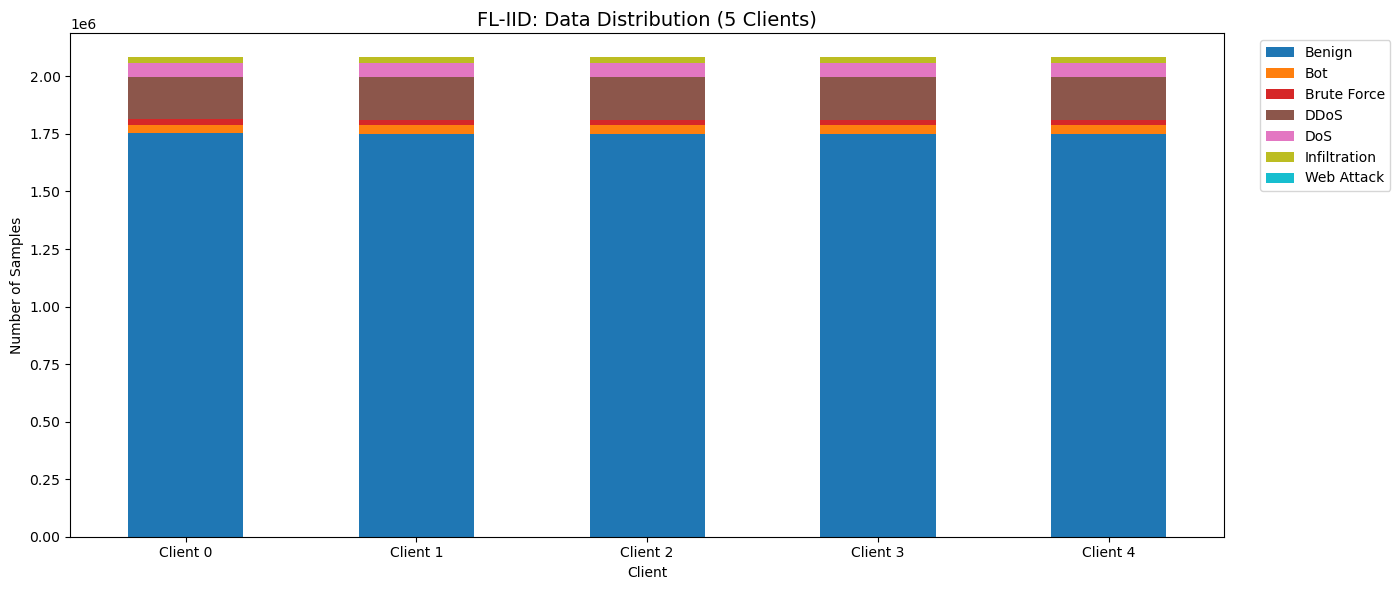


FL-IID (5 clients) (20 rounds, 5 clients)...
  Round 1/20 | Acc: 0.8918, Loss: 0.3609
  Round 2/20 | Acc: 0.9866, Loss: 0.0603
  Round 3/20 | Acc: 0.9644, Loss: 0.2146
  Round 4/20 | Acc: 0.9588, Loss: 0.2555
  Round 5/20 | Acc: 0.9572, Loss: 0.4908
  Round 6/20 | Acc: 0.9883, Loss: 0.0525
  Round 7/20 | Acc: 0.9661, Loss: 0.1104
  Round 8/20 | Acc: 0.9885, Loss: 0.0514
  Round 9/20 | Acc: 0.9885, Loss: 0.0509
  Round 10/20 | Acc: 0.9886, Loss: 0.0508
  Round 11/20 | Acc: 0.9886, Loss: 0.0508
  Round 12/20 | Acc: 0.9886, Loss: 0.0508
  Round 13/20 | Acc: 0.9885, Loss: 0.0508
  Round 14/20 | Acc: 0.9884, Loss: 0.0513
  Round 15/20 | Acc: 0.9886, Loss: 0.0508
  Round 16/20 | Acc: 0.9885, Loss: 0.0510
  Round 17/20 | Acc: 0.9886, Loss: 0.0510
  Round 18/20 | Acc: 0.9886, Loss: 0.0509
  Round 19/20 | Acc: 0.9886, Loss: 0.0511
  Round 20/20 | Acc: 0.9886, Loss: 0.0509
Done! Best Acc: 0.9886 (Round 20)
Model & results saved!


In [6]:
np.random.seed(42)
tf.random.set_seed(42)

client_idx = distribute_iid(y_train, 5)
distribution_summary_table(client_idx, y_train, "IID Distribution (5 Clients)")
plot_distribution(client_idx, y_train,
                  title="FL-IID: Data Distribution (5 Clients)",
                  save_name="fl_iid_5c_distribution.png")

iid_5c_model, iid_5c_acc, iid_5c_loss = run_fl_training(
    client_idx, X_train, y_train, X_val_cnn, y_val,
    NUM_FEATURES, NUM_CLASSES,
    label="FL-IID (5 clients)"
)

iid_5c_model.save(datapath + "fl_iid_5c_model.keras")
with open(datapath + "fl_iid_5c_results.json", "w") as f:
    json.dump({"acc": iid_5c_acc, "loss": iid_5c_loss}, f)
print("Model & results saved!")


  IID Distribution (10 Clients)


,Benign,Bot,Brute Force,DDoS,DoS,Infiltration,Web Attack,Total
Client 0,875787,18841,11551,92479,31187,11611,61,1041517
Client 1,876261,18939,11519,92112,31296,11326,64,1041517
Client 2,875049,18862,11567,93208,31330,11433,68,1041517
Client 3,876018,18894,11383,92373,31151,11628,69,1041516
Client 4,875857,18810,11658,92030,31640,11463,58,1041516
Client 5,875714,18915,11467,92508,31409,11438,65,1041516
Client 6,875656,19173,11635,92363,31235,11378,76,1041516
Client 7,875459,18831,11790,92355,31596,11420,65,1041516
Client 8,875490,18949,11536,92609,31551,11334,47,1041516
Client 9,876187,18848,11619,92156,31153,11489,64,1041516


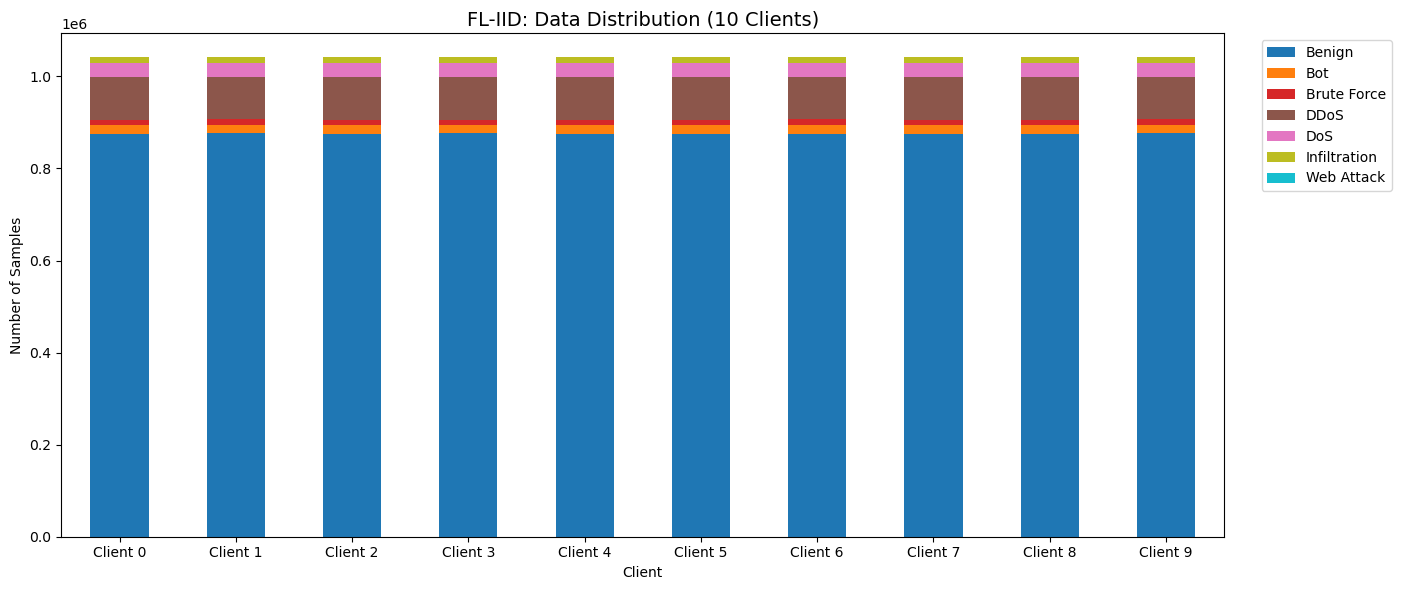


FL-IID (10 clients) (20 rounds, 10 clients)...
  Round 1/20 | Acc: 0.8412, Loss: 1.0024
  Round 2/20 | Acc: 0.9876, Loss: 0.0563
  Round 3/20 | Acc: 0.9857, Loss: 0.0648
  Round 4/20 | Acc: 0.9879, Loss: 0.0549
  Round 5/20 | Acc: 0.9881, Loss: 0.0531
  Round 6/20 | Acc: 0.9882, Loss: 0.0534
  Round 7/20 | Acc: 0.9880, Loss: 0.0538
  Round 8/20 | Acc: 0.9882, Loss: 0.0528
  Round 9/20 | Acc: 0.9884, Loss: 0.0519
  Round 10/20 | Acc: 0.9884, Loss: 0.0517
  Round 11/20 | Acc: 0.9885, Loss: 0.0516
  Round 12/20 | Acc: 0.9880, Loss: 0.0524
  Round 13/20 | Acc: 0.9876, Loss: 0.0533
  Round 14/20 | Acc: 0.9884, Loss: 0.0518
  Round 15/20 | Acc: 0.9882, Loss: 0.0521
  Round 16/20 | Acc: 0.9883, Loss: 0.0517
  Round 17/20 | Acc: 0.9885, Loss: 0.0513
  Round 18/20 | Acc: 0.9886, Loss: 0.0511
  Round 19/20 | Acc: 0.9884, Loss: 0.0517
  Round 20/20 | Acc: 0.9884, Loss: 0.0514
Done! Best Acc: 0.9886 (Round 18)
Model & results saved!


In [7]:
np.random.seed(42)
tf.random.set_seed(42)

client_idx = distribute_iid(y_train, 10)
distribution_summary_table(client_idx, y_train, "IID Distribution (10 Clients)")
plot_distribution(client_idx, y_train,
                  title="FL-IID: Data Distribution (10 Clients)",
                  save_name="fl_iid_10c_distribution.png")

iid_10c_model, iid_10c_acc, iid_10c_loss = run_fl_training(
    client_idx, X_train, y_train, X_val_cnn, y_val,
    NUM_FEATURES, NUM_CLASSES,
    label="FL-IID (10 clients)"
)

iid_10c_model.save(datapath + "fl_iid_10c_model.keras")
with open(datapath + "fl_iid_10c_results.json", "w") as f:
    json.dump({"acc": iid_10c_acc, "loss": iid_10c_loss}, f)
print("Model & results saved!")


  IID Distribution (15 Clients)


,Benign,Bot,Brute Force,DDoS,DoS,Infiltration,Web Attack,Total
Client 0,583937,12668,7787,61570,20674,7667,42,694345
Client 1,583544,12475,7681,61903,21000,7708,34,694345
Client 2,584568,12637,7602,61118,20809,7562,49,694345
Client 3,583131,12550,7779,62272,20921,7643,48,694344
Client 4,583940,12622,7555,61694,20806,7684,43,694344
Client 5,583995,12584,7616,61615,20754,7734,46,694344
Client 6,583572,12679,7829,61546,21078,7600,40,694344
Client 7,584011,12531,7614,61523,21007,7614,44,694344
Client 8,583988,12515,7682,61469,20964,7687,39,694344
Client 9,583697,12761,7770,61765,20665,7640,46,694344


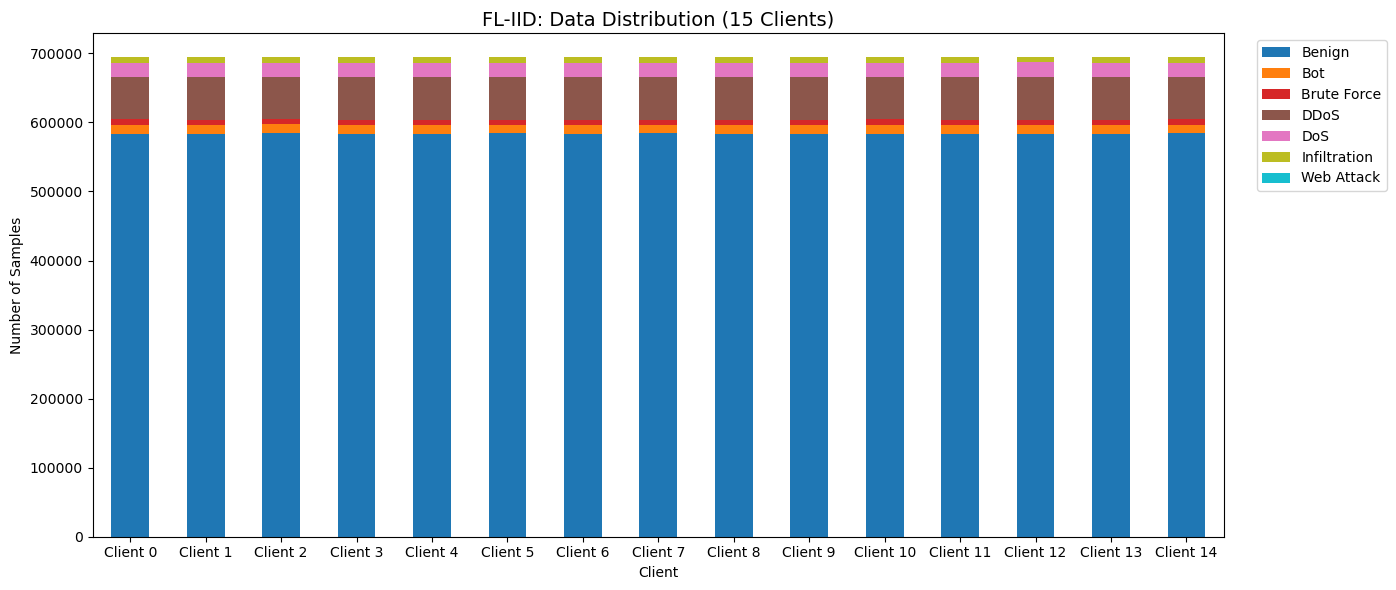


FL-IID (15 clients) (20 rounds, 15 clients)...
  Round 1/20WARNING:tensorflow:From C:\Users\loke\anaconda3\Lib\site-packages\keras\src\backend\common\global_state.py:82: The name tf.reset_default_graph is deprecated. Please use tf.compat.v1.reset_default_graph instead.

 | Acc: 0.8433, Loss: 1.7207
  Round 2/20 | Acc: 0.9817, Loss: 0.0826
  Round 3/20 | Acc: 0.9847, Loss: 0.0638
  Round 4/20 | Acc: 0.9867, Loss: 0.0615
  Round 5/20 | Acc: 0.9869, Loss: 0.0592
  Round 6/20 | Acc: 0.9873, Loss: 0.0547
  Round 7/20 | Acc: 0.9870, Loss: 0.0590
  Round 8/20 | Acc: 0.9870, Loss: 0.0576
  Round 9/20 | Acc: 0.9871, Loss: 0.0566
  Round 10/20 | Acc: 0.9873, Loss: 0.0559
  Round 11/20 | Acc: 0.9872, Loss: 0.0543
  Round 12/20 | Acc: 0.9863, Loss: 0.0591
  Round 13/20 | Acc: 0.9882, Loss: 0.0523
  Round 14/20 | Acc: 0.9873, Loss: 0.0558
  Round 15/20 | Acc: 0.9873, Loss: 0.0588
  Round 16/20 | Acc: 0.9874, Loss: 0.0550
  Round 17/20 | Acc: 0.9874, Loss: 0.0558
  Round 18/20 | Acc: 0.9879, Loss: 

In [4]:
np.random.seed(42)
tf.random.set_seed(42)

client_idx = distribute_iid(y_train, 15)
distribution_summary_table(client_idx, y_train, "IID Distribution (15 Clients)")
plot_distribution(client_idx, y_train,
                  title="FL-IID: Data Distribution (15 Clients)",
                  save_name="fl_iid_15c_distribution.png")

iid_15c_model, iid_15c_acc, iid_15c_loss = run_fl_training(
    client_idx, X_train, y_train, X_val_cnn, y_val,
    NUM_FEATURES, NUM_CLASSES,
    label="FL-IID (15 clients)"
)

iid_15c_model.save(datapath + "fl_iid_15c_model.keras")
with open(datapath + "fl_iid_15c_results.json", "w") as f:
    json.dump({"acc": iid_15c_acc, "loss": iid_15c_loss}, f)
print("Model & results saved!")

---
## 5. FL-Non-IID Experiments
Run each cell independently.


  Non-IID Distribution (5 Clients)


,Benign,Bot,Brute Force,DDoS,DoS,Infiltration,Web Attack,Total
Client 0,1751496,136079,2327,18666,6164,25147,462,1940341
Client 1,1751496,41661,83285,18593,6383,2286,135,1903839
Client 2,1751496,3779,25490,665358,6245,2312,10,2454690
Client 3,1751495,3754,2334,203306,225659,2279,14,2188841
Client 4,1751495,3789,2289,18270,69097,82496,16,1927452
Total,8757478,189062,115725,924193,313548,114520,637,10415163


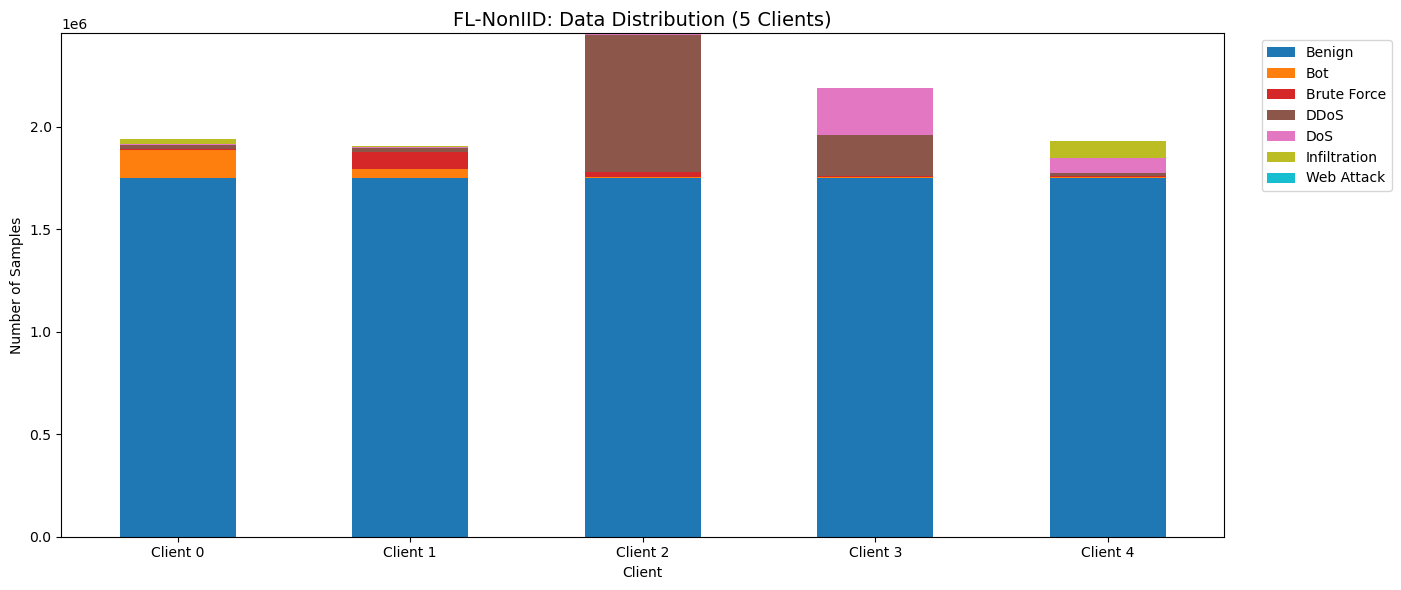


FL-NonIID (5 clients) (20 rounds, 5 clients)...
  Round 1/20 | Acc: 0.8408, Loss: 6.6558
  Round 2/20 | Acc: 0.8973, Loss: 0.4468
  Round 3/20 | Acc: 0.9876, Loss: 0.0617
  Round 4/20 | Acc: 0.9879, Loss: 0.0579
  Round 5/20 | Acc: 0.9879, Loss: 0.0589
  Round 6/20 | Acc: 0.9880, Loss: 0.0590
  Round 7/20 | Acc: 0.9885, Loss: 0.0575
  Round 8/20 | Acc: 0.9881, Loss: 0.0581
  Round 9/20 | Acc: 0.9884, Loss: 0.0570
  Round 10/20 | Acc: 0.9884, Loss: 0.0580
  Round 11/20 | Acc: 0.9883, Loss: 0.0587
  Round 12/20 | Acc: 0.9883, Loss: 0.0585
  Round 13/20 | Acc: 0.9882, Loss: 0.0588
  Round 14/20 | Acc: 0.9883, Loss: 0.0574
  Round 15/20 | Acc: 0.9884, Loss: 0.0585
  Round 16/20 | Acc: 0.9880, Loss: 0.0586
  Round 17/20 | Acc: 0.9883, Loss: 0.0591
  Round 18/20 | Acc: 0.9847, Loss: 0.0670
  Round 19/20 | Acc: 0.9883, Loss: 0.0585
  Round 20/20 | Acc: 0.9882, Loss: 0.0592
Done! Best Acc: 0.9885 (Round 7)
Model & results saved!


In [5]:
np.random.seed(42)
tf.random.set_seed(42)

client_idx = distribute_noniid(y_train, 5)
distribution_summary_table(client_idx, y_train, "Non-IID Distribution (5 Clients)")
plot_distribution(client_idx, y_train,
                  title="FL-NonIID: Data Distribution (5 Clients)",
                  save_name="fl_noniid_5c_distribution.png")

noniid_5c_model, noniid_5c_acc, noniid_5c_loss = run_fl_training(
    client_idx, X_train, y_train, X_val_cnn, y_val,
    NUM_FEATURES, NUM_CLASSES,
    label="FL-NonIID (5 clients)"
)

noniid_5c_model.save(datapath + "fl_noniid_5c_model.keras")
with open(datapath + "fl_noniid_5c_results.json", "w") as f:
    json.dump({"acc": noniid_5c_acc, "loss": noniid_5c_loss}, f)
print("Model & results saved!")


  Non-IID Distribution (10 Clients)


,Benign,Bot,Brute Force,DDoS,DoS,Infiltration,Web Attack,Total
Client 0,875748,134226,1179,9346,3061,1149,7,1024716
Client 1,875748,39754,82173,9453,3211,1142,6,1011487
Client 2,875748,1916,24311,656170,3130,1146,4,1562425
Client 3,875748,1866,1196,193964,222526,1145,7,1296452
Client 4,875748,1907,1119,9041,65872,81304,8,1034999
Client 5,875748,1936,1147,9253,3150,24070,453,915757
Client 6,875748,1863,1181,9214,3158,1150,132,892446
Client 7,875748,1833,1186,9221,3088,1189,8,892273
Client 8,875747,1853,1131,9353,3137,1091,4,892316
Client 9,875747,1908,1102,9178,3215,1134,8,892292


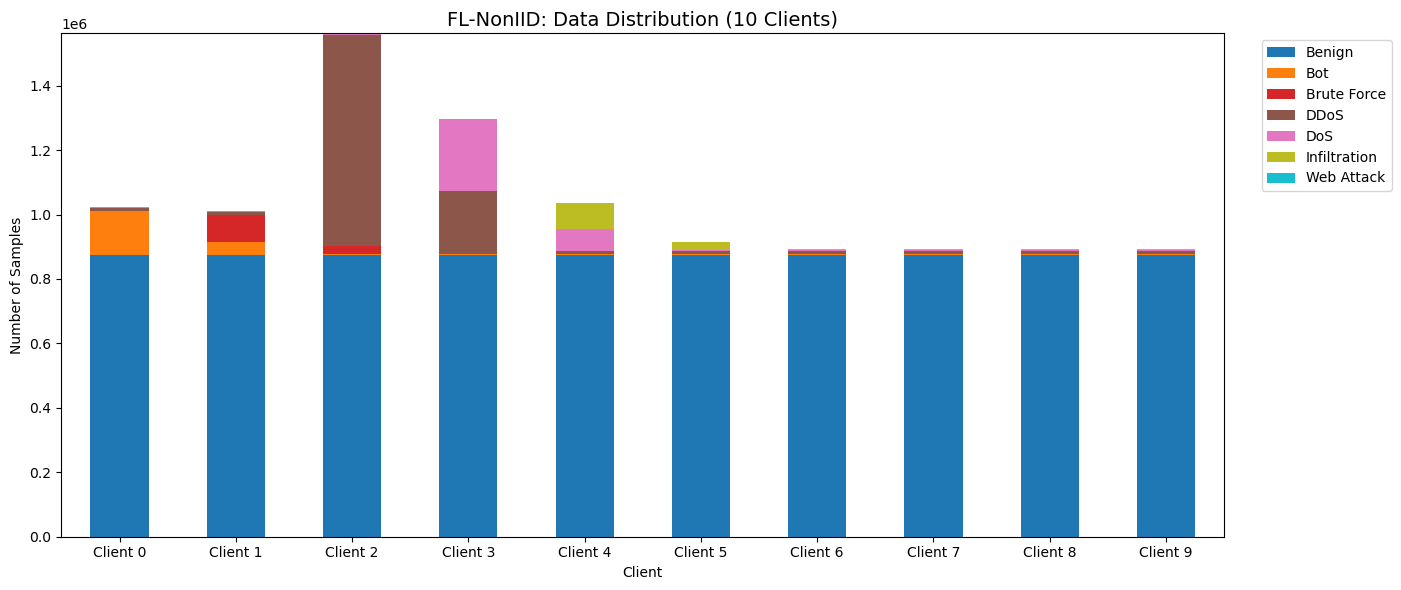


FL-NonIID (10 clients) (20 rounds, 10 clients)...
  Round 1/20 | Acc: 0.8328, Loss: 2.3225
  Round 2/20 | Acc: 0.9682, Loss: 0.1116
  Round 3/20 | Acc: 0.9860, Loss: 0.0656
  Round 4/20 | Acc: 0.9867, Loss: 0.0633
  Round 5/20 | Acc: 0.9869, Loss: 0.0639
  Round 6/20 | Acc: 0.9863, Loss: 0.0639
  Round 7/20 | Acc: 0.9867, Loss: 0.0614
  Round 8/20 | Acc: 0.9844, Loss: 0.0689
  Round 9/20 | Acc: 0.9871, Loss: 0.0616
  Round 10/20 | Acc: 0.9870, Loss: 0.0617
  Round 11/20 | Acc: 0.9864, Loss: 0.0622
  Round 12/20 | Acc: 0.9870, Loss: 0.0623
  Round 13/20 | Acc: 0.9871, Loss: 0.0617
  Round 14/20 | Acc: 0.9872, Loss: 0.0618
  Round 15/20 | Acc: 0.9864, Loss: 0.0615
  Round 16/20 | Acc: 0.9871, Loss: 0.0620
  Round 17/20 | Acc: 0.9868, Loss: 0.0616
  Round 18/20 | Acc: 0.9871, Loss: 0.0621
  Round 19/20 | Acc: 0.9872, Loss: 0.0612
  Round 20/20 | Acc: 0.9865, Loss: 0.0616
Done! Best Acc: 0.9872 (Round 19)
Model & results saved!


In [6]:
np.random.seed(42)
tf.random.set_seed(42)

client_idx = distribute_noniid(y_train, 10)
distribution_summary_table(client_idx, y_train, "Non-IID Distribution (10 Clients)")
plot_distribution(client_idx, y_train,
                  title="FL-NonIID: Data Distribution (10 Clients)",
                  save_name="fl_noniid_10c_distribution.png")

noniid_10c_model, noniid_10c_acc, noniid_10c_loss = run_fl_training(
    client_idx, X_train, y_train, X_val_cnn, y_val,
    NUM_FEATURES, NUM_CLASSES,
    label="FL-NonIID (10 clients)"
)

noniid_10c_model.save(datapath + "fl_noniid_10c_model.keras")
with open(datapath + "fl_noniid_10c_results.json", "w") as f:
    json.dump({"acc": noniid_10c_acc, "loss": noniid_10c_loss}, f)
print("Model & results saved!")


  Non-IID Distribution (15 Clients)


,Benign,Bot,Brute Force,DDoS,DoS,Infiltration,Web Attack,Total
Client 0,583832,133621,728,6128,2070,753,5,727137
Client 1,583832,39060,81814,6276,2081,753,3,713819
Client 2,583832,1289,23928,652985,2157,782,4,1264977
Client 3,583832,1223,790,190950,221495,755,9,999054
Client 4,583832,1256,765,6037,64772,80971,3,737636
Client 5,583832,1298,799,6163,2031,23709,449,618281
Client 6,583832,1250,774,6170,2150,772,129,595077
Client 7,583832,1206,759,6189,2084,750,4,594824
Client 8,583832,1246,812,6231,2114,735,3,594973
Client 9,583832,1262,733,6126,2083,787,5,594828


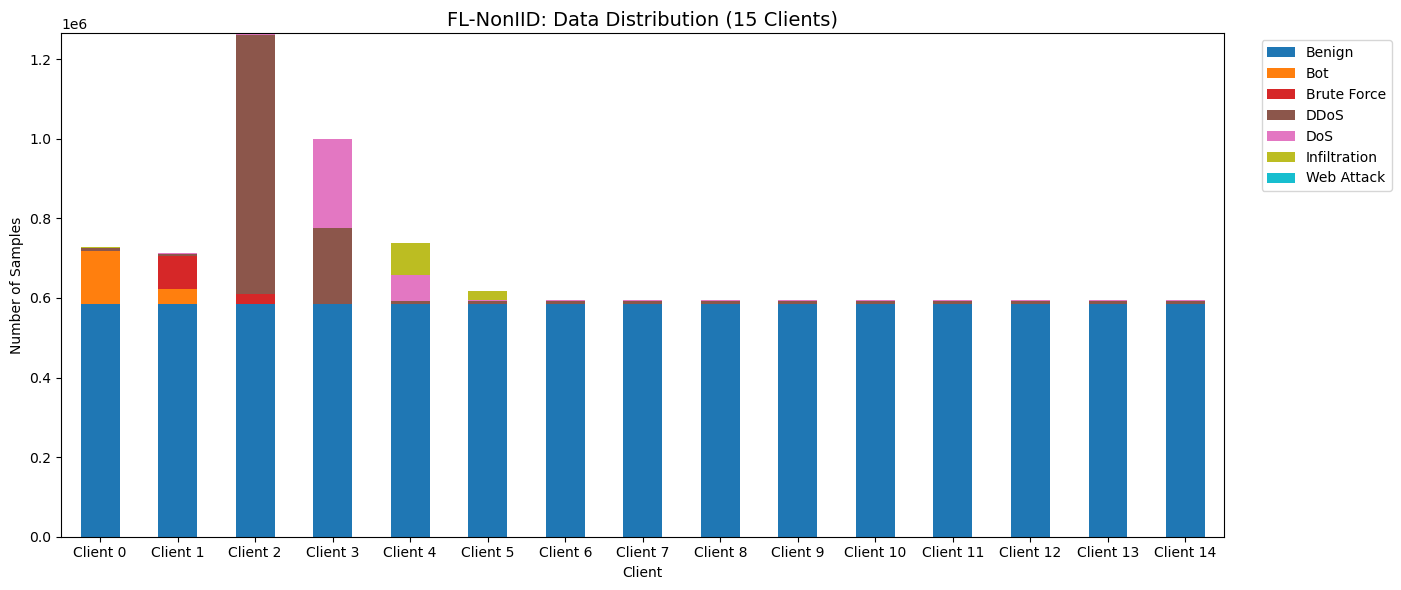


FL-NonIID (15 clients) (20 rounds, 15 clients)...
  Round 1/20WARNING:tensorflow:From C:\Users\loke\anaconda3\Lib\site-packages\keras\src\backend\common\global_state.py:82: The name tf.reset_default_graph is deprecated. Please use tf.compat.v1.reset_default_graph instead.

 | Acc: 0.8411, Loss: 1.7798
  Round 2/20 | Acc: 0.9811, Loss: 0.0872
  Round 3/20 | Acc: 0.9860, Loss: 0.0678
  Round 4/20 | Acc: 0.9863, Loss: 0.0667
  Round 5/20 | Acc: 0.9866, Loss: 0.0641
  Round 6/20 | Acc: 0.9866, Loss: 0.0671
  Round 7/20 | Acc: 0.9869, Loss: 0.0654
  Round 8/20 | Acc: 0.9870, Loss: 0.0652
  Round 9/20 | Acc: 0.9870, Loss: 0.0641
  Round 10/20 | Acc: 0.9871, Loss: 0.0632
  Round 11/20 | Acc: 0.9865, Loss: 0.0624
  Round 12/20 | Acc: 0.9873, Loss: 0.0627
  Round 13/20 | Acc: 0.9873, Loss: 0.0626
  Round 14/20 | Acc: 0.9873, Loss: 0.0636
  Round 15/20 | Acc: 0.9873, Loss: 0.0625
  Round 16/20 | Acc: 0.9873, Loss: 0.0627
  Round 17/20 | Acc: 0.9873, Loss: 0.0640
  Round 18/20 | Acc: 0.9869, Los

In [4]:
np.random.seed(42)
tf.random.set_seed(42)

client_idx = distribute_noniid(y_train, 15)
distribution_summary_table(client_idx, y_train, "Non-IID Distribution (15 Clients)")
plot_distribution(client_idx, y_train,
                  title="FL-NonIID: Data Distribution (15 Clients)",
                  save_name="fl_noniid_15c_distribution.png")

noniid_15c_model, noniid_15c_acc, noniid_15c_loss = run_fl_training(
    client_idx, X_train, y_train, X_val_cnn, y_val,
    NUM_FEATURES, NUM_CLASSES,
    label="FL-NonIID (15 clients)"
)

noniid_15c_model.save(datapath + "fl_noniid_15c_model.keras")
with open(datapath + "fl_noniid_15c_results.json", "w") as f:
    json.dump({"acc": noniid_15c_acc, "loss": noniid_15c_loss}, f)
print("Model & results saved!")

---
## 6. FL-Extreme Non-IID (10 Clients)
- Client 0-5: each gets **one exclusive attack type** + Benign
- Client 6-9: **only Benign**


  Extreme Non-IID Distribution (10 Clients)


,Benign,Bot,Brute Force,DDoS,DoS,Infiltration,Web Attack,Total
Client 0,875748,189062,0,0,0,0,0,1064810
Client 1,875748,0,115725,0,0,0,0,991473
Client 2,875748,0,0,924193,0,0,0,1799941
Client 3,875748,0,0,0,313548,0,0,1189296
Client 4,875748,0,0,0,0,114520,0,990268
Client 5,875748,0,0,0,0,0,637,876385
Client 6,875748,0,0,0,0,0,0,875748
Client 7,875748,0,0,0,0,0,0,875748
Client 8,875747,0,0,0,0,0,0,875747
Client 9,875747,0,0,0,0,0,0,875747


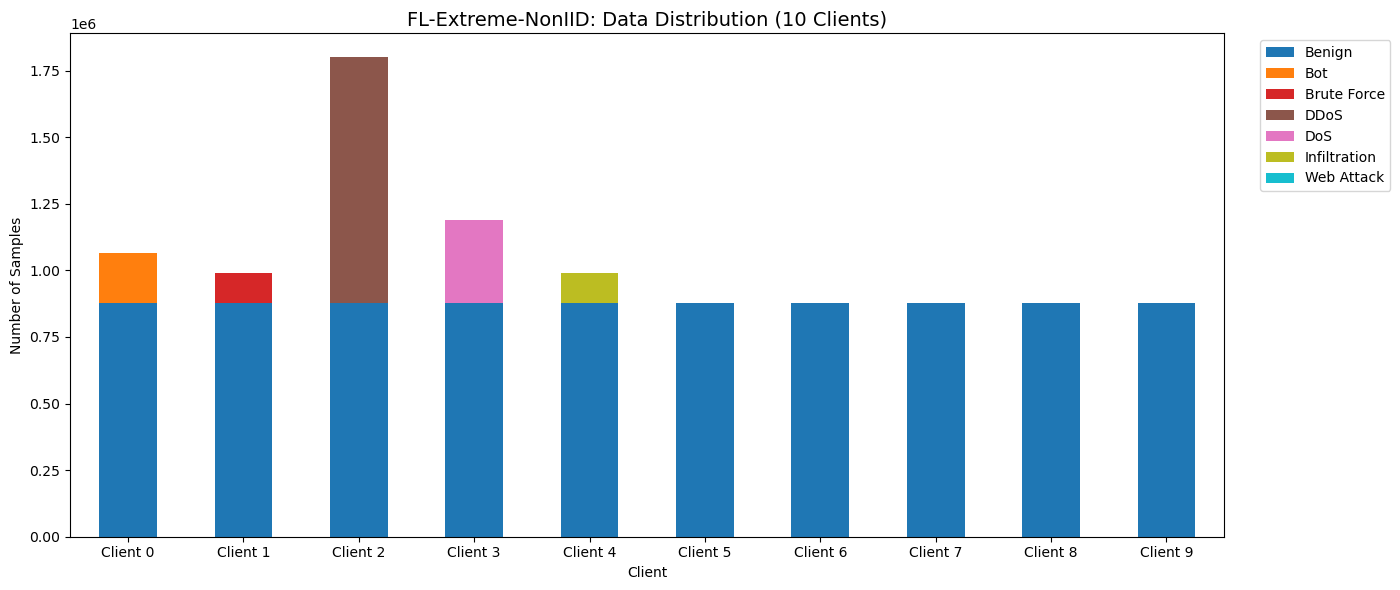


FL-Extreme-NonIID (10 clients) (20 rounds, 10 clients)...
  Round 1/20WARNING:tensorflow:From C:\Users\loke\anaconda3\Lib\site-packages\keras\src\backend\common\global_state.py:82: The name tf.reset_default_graph is deprecated. Please use tf.compat.v1.reset_default_graph instead.

 | Acc: 0.8408, Loss: 8.7579
  Round 2/20 | Acc: 0.8408, Loss: 3.4103
  Round 3/20 | Acc: 0.8408, Loss: 3.6335
  Round 4/20 | Acc: 0.8408, Loss: 4.1109
  Round 5/20 | Acc: 0.8408, Loss: 6.9905
  Round 6/20 | Acc: 0.8408, Loss: 4.9535
  Round 7/20 | Acc: 0.8408, Loss: 5.7138
  Round 8/20 | Acc: 0.8408, Loss: 4.3919
  Round 9/20 | Acc: 0.8408, Loss: 5.4446
  Round 10/20 | Acc: 0.8408, Loss: 3.3593
  Round 11/20 | Acc: 0.8408, Loss: 3.8971
  Round 12/20 | Acc: 0.8408, Loss: 8.2176
  Round 13/20 | Acc: 0.8409, Loss: 5.7723
  Round 14/20 | Acc: 0.8413, Loss: 5.1933
  Round 15/20 | Acc: 0.8409, Loss: 7.1136
  Round 16/20 | Acc: 0.8409, Loss: 6.7314
  Round 17/20 | Acc: 0.8517, Loss: 7.1465
  Round 18/20 | Acc: 0.8

In [5]:
np.random.seed(42)
tf.random.set_seed(42)

extreme_client_idx = distribute_extreme_noniid(y_train, 10)
distribution_summary_table(extreme_client_idx, y_train, "Extreme Non-IID Distribution (10 Clients)")
plot_distribution(extreme_client_idx, y_train,
                  title="FL-Extreme-NonIID: Data Distribution (10 Clients)",
                  save_name="fl_extreme_noniid_distribution.png")

extreme_model, extreme_acc, extreme_loss = run_fl_training(
    extreme_client_idx, X_train, y_train, X_val_cnn, y_val,
    NUM_FEATURES, NUM_CLASSES,
    label="FL-Extreme-NonIID (10 clients)"
)

extreme_model.save(datapath + "fl_extreme_noniid_model.keras")
with open(datapath + "fl_extreme_noniid_results.json", "w") as f:
    json.dump({"acc": extreme_acc, "loss": extreme_loss}, f)
print("Model & results saved!")

---
## 7. FL Non-IID (Epochs=1 & Epochs=10）


In [4]:
np.random.seed(42)
tf.random.set_seed(42)
client_idx = distribute_noniid(y_train, 10)

# Temporarily change LOCAL_EPOCHS
LOCAL_EPOCHS_ORIG = LOCAL_EPOCHS

LOCAL_EPOCHS = 1
print(f"Running with LOCAL_EPOCHS = {LOCAL_EPOCHS}")

noniid_10c_e1_model, noniid_10c_e1_acc, noniid_10c_e1_loss = run_fl_training(
    client_idx, X_train, y_train, X_val_cnn, y_val,
    NUM_FEATURES, NUM_CLASSES,
    label="FL-NonIID (10c, E=1)"
)
noniid_10c_e1_model.save(datapath + "fl_noniid_10c_e1_model.keras")
with open(datapath + "fl_noniid_10c_e1_results.json", "w") as f:
    json.dump({"acc": noniid_10c_e1_acc, "loss": noniid_10c_e1_loss}, f)

LOCAL_EPOCHS = LOCAL_EPOCHS_ORIG
print("Done! LOCAL_EPOCHS restored.")

Running with LOCAL_EPOCHS = 1

FL-NonIID (10c, E=1) (20 rounds, 10 clients)...
  Round 1/20WARNING:tensorflow:From C:\Users\loke\anaconda3\Lib\site-packages\keras\src\backend\common\global_state.py:82: The name tf.reset_default_graph is deprecated. Please use tf.compat.v1.reset_default_graph instead.

 | Acc: 0.8429, Loss: 0.7833
  Round 2/20 | Acc: 0.9644, Loss: 0.1526
  Round 3/20 | Acc: 0.9830, Loss: 0.0745
  Round 4/20 | Acc: 0.9845, Loss: 0.0652
  Round 5/20 | Acc: 0.9620, Loss: 0.3248
  Round 6/20 | Acc: 0.9732, Loss: 0.0979
  Round 7/20 | Acc: 0.9861, Loss: 0.0597
  Round 8/20 | Acc: 0.9860, Loss: 0.0590
  Round 9/20 | Acc: 0.9864, Loss: 0.0600
  Round 10/20 | Acc: 0.9844, Loss: 0.0729
  Round 11/20 | Acc: 0.9846, Loss: 0.0686
  Round 12/20 | Acc: 0.9860, Loss: 0.0600
  Round 13/20 | Acc: 0.9603, Loss: 0.1208
  Round 14/20 | Acc: 0.9870, Loss: 0.0604
  Round 15/20 | Acc: 0.9863, Loss: 0.0609
  Round 16/20 | Acc: 0.9870, Loss: 0.0615
  Round 17/20 | Acc: 0.9868, Loss: 0.0614
  Ro

In [5]:
np.random.seed(42)
tf.random.set_seed(42)
client_idx = distribute_noniid(y_train, 10)

LOCAL_EPOCHS_ORIG = LOCAL_EPOCHS

LOCAL_EPOCHS = 10
print(f"Running with LOCAL_EPOCHS = {LOCAL_EPOCHS}")

noniid_10c_e10_model, noniid_10c_e10_acc, noniid_10c_e10_loss = run_fl_training(
    client_idx, X_train, y_train, X_val_cnn, y_val,
    NUM_FEATURES, NUM_CLASSES,
    label="FL-NonIID (10c, E=10)"
)
noniid_10c_e10_model.save(datapath + "fl_noniid_10c_e10_model.keras")
with open(datapath + "fl_noniid_10c_e10_results.json", "w") as f:
    json.dump({"acc": noniid_10c_e10_acc, "loss": noniid_10c_e10_loss}, f)

LOCAL_EPOCHS = LOCAL_EPOCHS_ORIG
print("Done! LOCAL_EPOCHS restored.")

Running with LOCAL_EPOCHS = 10

FL-NonIID (10c, E=10) (20 rounds, 10 clients)...
  Round 1/20 | Acc: 0.8411, Loss: 5.9291
  Round 2/20 | Acc: 0.9804, Loss: 0.0893
  Round 3/20 | Acc: 0.9871, Loss: 0.0647
  Round 4/20 | Acc: 0.9872, Loss: 0.0629
  Round 5/20 | Acc: 0.9872, Loss: 0.0620
  Round 6/20 | Acc: 0.9864, Loss: 0.0618
  Round 7/20 | Acc: 0.9871, Loss: 0.0619
  Round 8/20 | Acc: 0.9864, Loss: 0.0612
  Round 9/20 | Acc: 0.9861, Loss: 0.0619
  Round 10/20 | Acc: 0.9862, Loss: 0.0623
  Round 11/20 | Acc: 0.9860, Loss: 0.0620
  Round 12/20 | Acc: 0.9871, Loss: 0.0611
  Round 13/20 | Acc: 0.9881, Loss: 0.0610
  Round 14/20 | Acc: 0.9872, Loss: 0.0611
  Round 15/20 | Acc: 0.9868, Loss: 0.0633
  Round 16/20 | Acc: 0.9873, Loss: 0.0630
  Round 17/20 | Acc: 0.9872, Loss: 0.0642
  Round 18/20 | Acc: 0.9873, Loss: 0.0638
  Round 19/20 | Acc: 0.9873, Loss: 0.0637
  Round 20/20 | Acc: 0.9872, Loss: 0.0651
Done! Best Acc: 0.9881 (Round 13)
Done! LOCAL_EPOCHS restored.


In [7]:
import json

noniid_10c_acc = json.load(open(datapath + "fl_noniid_10c_results.json"))["acc"]
noniid_10c_loss = json.load(open(datapath + "fl_noniid_10c_results.json"))["loss"]

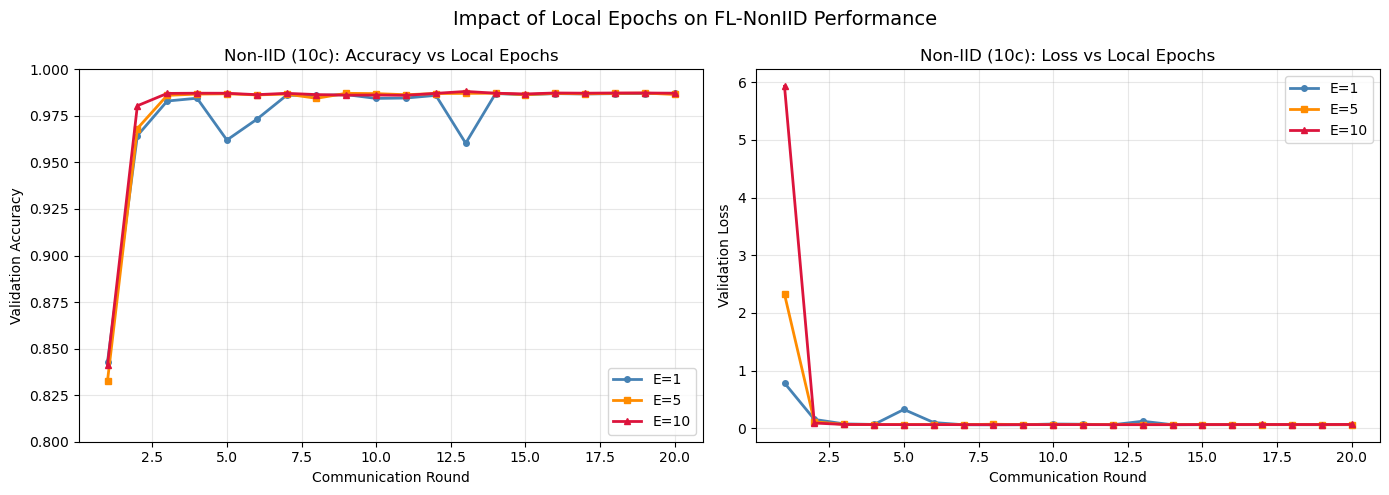

E=1  Best Acc: 0.9872
E=5  Best Acc: 0.9872
E=10 Best Acc: 0.9881


In [8]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(range(1, 21), noniid_10c_e1_acc, marker='o', markersize=4, linewidth=2, label='E=1', color='steelblue')
ax1.plot(range(1, 21), noniid_10c_acc, marker='s', markersize=4, linewidth=2, label='E=5', color='darkorange')
ax1.plot(range(1, 21), noniid_10c_e10_acc, marker='^', markersize=4, linewidth=2, label='E=10', color='crimson')
ax1.set_title('Non-IID (10c): Accuracy vs Local Epochs')
ax1.set_xlabel('Communication Round')
ax1.set_ylabel('Validation Accuracy')
ax1.legend()
ax1.grid(True, alpha=0.3)
ax1.set_ylim([0.8, 1.0])

ax2.plot(range(1, 21), noniid_10c_e1_loss, marker='o', markersize=4, linewidth=2, label='E=1', color='steelblue')
ax2.plot(range(1, 21), noniid_10c_loss, marker='s', markersize=4, linewidth=2, label='E=5', color='darkorange')
ax2.plot(range(1, 21), noniid_10c_e10_loss, marker='^', markersize=4, linewidth=2, label='E=10', color='crimson')
ax2.set_title('Non-IID (10c): Loss vs Local Epochs')
ax2.set_xlabel('Communication Round')
ax2.set_ylabel('Validation Loss')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.suptitle('Impact of Local Epochs on FL-NonIID Performance', fontsize=14)
plt.tight_layout()
plt.savefig(datapath + "fl_local_epochs_comparison.png", dpi=150)
plt.show()

print(f"E=1  Best Acc: {max(noniid_10c_e1_acc):.4f}")
print(f"E=5  Best Acc: {max(noniid_10c_acc):.4f}")
print(f"E=10 Best Acc: {max(noniid_10c_e10_acc):.4f}")

---
## 8. Load Saved Results (Optional)
**Use this after kernel restart to load previously trained results without retraining.**
Only run this if you already trained and saved the models above.

In [9]:
# Load all saved results for comparison plots
# IID
iid_5c_acc = json.load(open(datapath+"fl_iid_5c_results.json"))["acc"]
iid_5c_loss = json.load(open(datapath+"fl_iid_5c_results.json"))["loss"]
iid_10c_acc = json.load(open(datapath+"fl_iid_10c_results.json"))["acc"]
iid_10c_loss = json.load(open(datapath+"fl_iid_10c_results.json"))["loss"]
iid_15c_acc = json.load(open(datapath+"fl_iid_15c_results.json"))["acc"]
iid_15c_loss = json.load(open(datapath+"fl_iid_15c_results.json"))["loss"]

# Non-IID
noniid_5c_acc = json.load(open(datapath+"fl_noniid_5c_results.json"))["acc"]
noniid_5c_loss = json.load(open(datapath+"fl_noniid_5c_results.json"))["loss"]
noniid_10c_acc = json.load(open(datapath+"fl_noniid_10c_results.json"))["acc"]
noniid_10c_loss = json.load(open(datapath+"fl_noniid_10c_results.json"))["loss"]
noniid_15c_acc = json.load(open(datapath+"fl_noniid_15c_results.json"))["acc"]
noniid_15c_loss = json.load(open(datapath+"fl_noniid_15c_results.json"))["loss"]

# Extreme Non-IID
extreme_acc = json.load(open(datapath+"fl_extreme_noniid_results.json"))["acc"]
extreme_loss = json.load(open(datapath+"fl_extreme_noniid_results.json"))["loss"]

# Load models (only if you need evaluation/confusion matrix)
iid_5c_model = keras.models.load_model(datapath+"fl_iid_5c_model.keras")
iid_10c_model = keras.models.load_model(datapath+"fl_iid_10c_model.keras")
iid_15c_model = keras.models.load_model(datapath+"fl_iid_15c_model.keras")
noniid_5c_model = keras.models.load_model(datapath+"fl_noniid_5c_model.keras")
noniid_10c_model = keras.models.load_model(datapath+"fl_noniid_10c_model.keras")
noniid_15c_model = keras.models.load_model(datapath+"fl_noniid_15c_model.keras")
extreme_model = keras.models.load_model(datapath+"fl_extreme_noniid_model.keras")

print("All saved results and models loaded!")

C:\Users\loke\anaconda3\Lib\site-packages\keras\src\saving\saving_lib.py:798: UserWarning: Skipping variable loading for optimizer 'adam', because it has 30 variables whereas the saved optimizer has 2 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


All saved results and models loaded!


---
## 9. Comparison: Impact of Client Count
**Requires:** All IID (5/10/15) and Non-IID (5/10/15) results loaded.

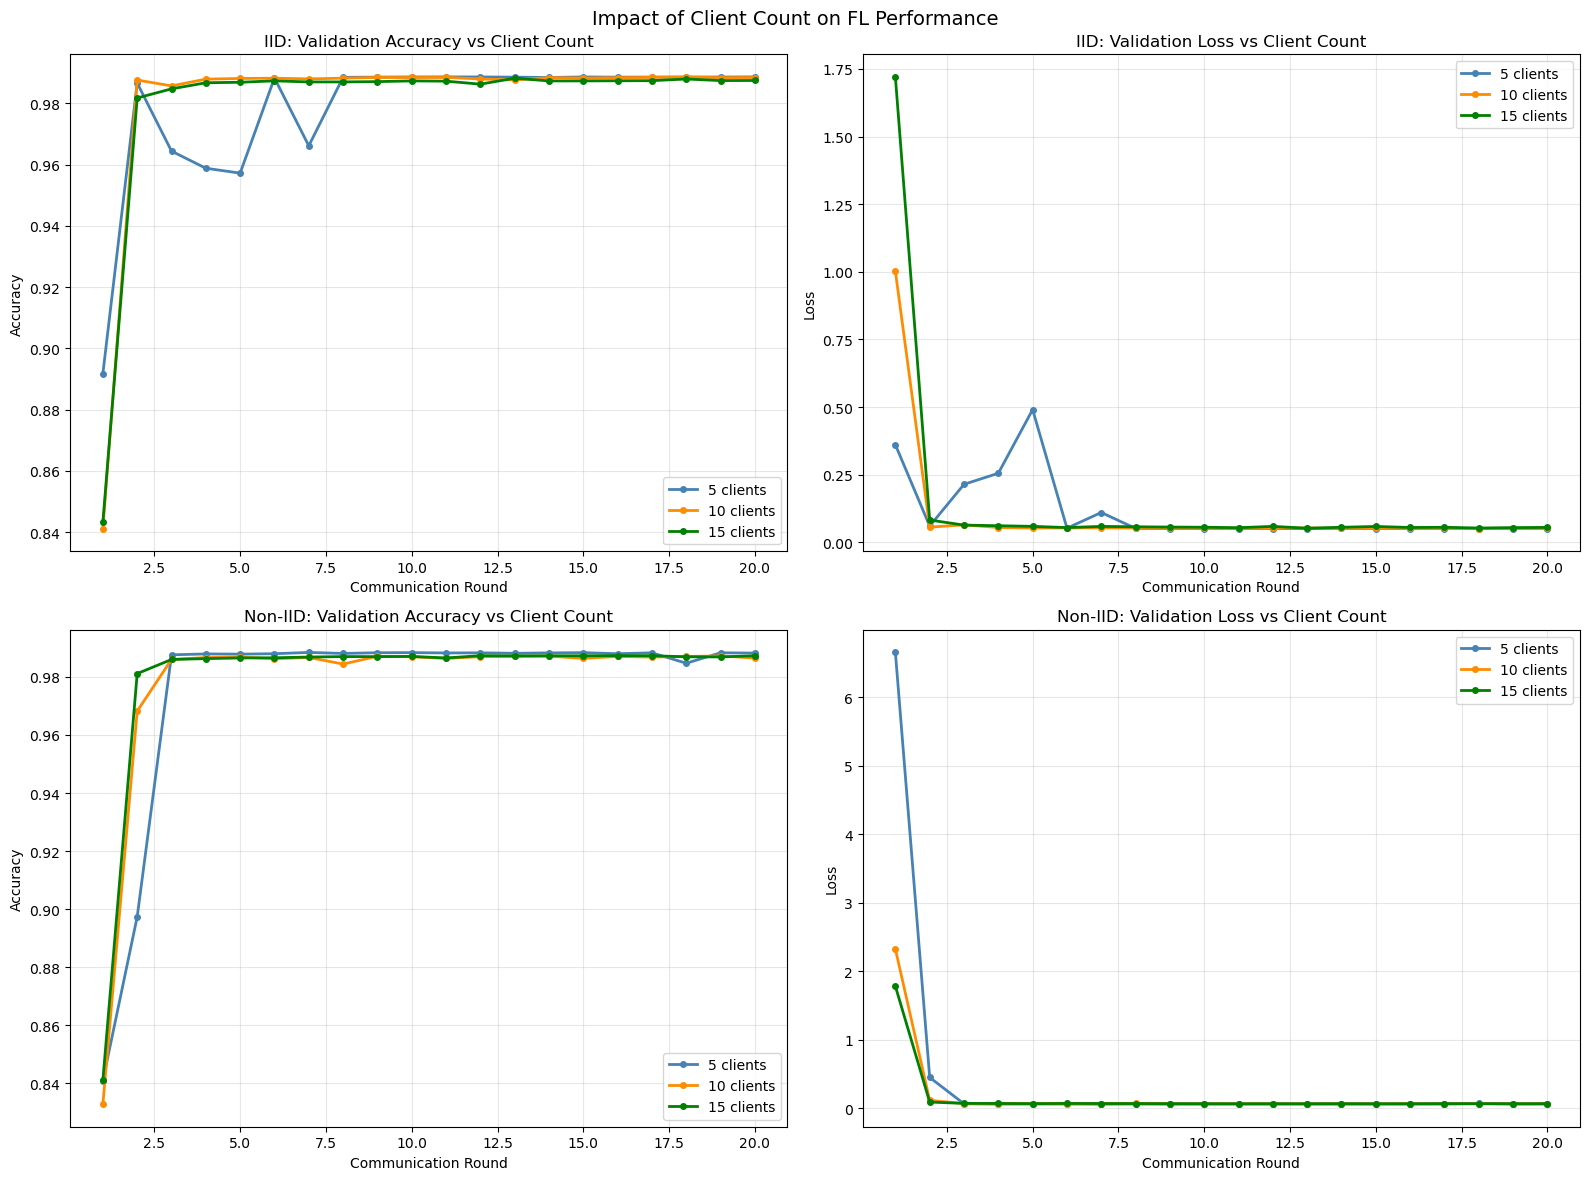

In [10]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
colors = {5: 'steelblue', 10: 'darkorange', 15: 'green'}

# IID Accuracy
for nc, acc in [(5, iid_5c_acc), (10, iid_10c_acc), (15, iid_15c_acc)]:
    axes[0,0].plot(range(1, NUM_ROUNDS+1), acc,
                   color=colors[nc], linewidth=2, marker='o', markersize=4,
                   label=f'{nc} clients')
axes[0,0].set_title('IID: Validation Accuracy vs Client Count')
axes[0,0].set_xlabel('Communication Round')
axes[0,0].set_ylabel('Accuracy')
axes[0,0].legend()
axes[0,0].grid(True, alpha=0.3)

# IID Loss
for nc, loss in [(5, iid_5c_loss), (10, iid_10c_loss), (15, iid_15c_loss)]:
    axes[0,1].plot(range(1, NUM_ROUNDS+1), loss,
                   color=colors[nc], linewidth=2, marker='o', markersize=4,
                   label=f'{nc} clients')
axes[0,1].set_title('IID: Validation Loss vs Client Count')
axes[0,1].set_xlabel('Communication Round')
axes[0,1].set_ylabel('Loss')
axes[0,1].legend()
axes[0,1].grid(True, alpha=0.3)

# Non-IID Accuracy
for nc, acc in [(5, noniid_5c_acc), (10, noniid_10c_acc), (15, noniid_15c_acc)]:
    axes[1,0].plot(range(1, NUM_ROUNDS+1), acc,
                   color=colors[nc], linewidth=2, marker='o', markersize=4,
                   label=f'{nc} clients')
axes[1,0].set_title('Non-IID: Validation Accuracy vs Client Count')
axes[1,0].set_xlabel('Communication Round')
axes[1,0].set_ylabel('Accuracy')
axes[1,0].legend()
axes[1,0].grid(True, alpha=0.3)

# Non-IID Loss
for nc, loss in [(5, noniid_5c_loss), (10, noniid_10c_loss), (15, noniid_15c_loss)]:
    axes[1,1].plot(range(1, NUM_ROUNDS+1), loss,
                   color=colors[nc], linewidth=2, marker='o', markersize=4,
                   label=f'{nc} clients')
axes[1,1].set_title('Non-IID: Validation Loss vs Client Count')
axes[1,1].set_xlabel('Communication Round')
axes[1,1].set_ylabel('Loss')
axes[1,1].legend()
axes[1,1].grid(True, alpha=0.3)

plt.suptitle('Impact of Client Count on FL Performance', fontsize=14)
plt.tight_layout()
plt.savefig(datapath + "fl_client_count_comparison.png", dpi=150)
plt.show()

## 10. Comparison: Impact of Data Distribution (10 Clients)
**Requires:** IID-10c, Non-IID-10c, Extreme-10c results loaded.

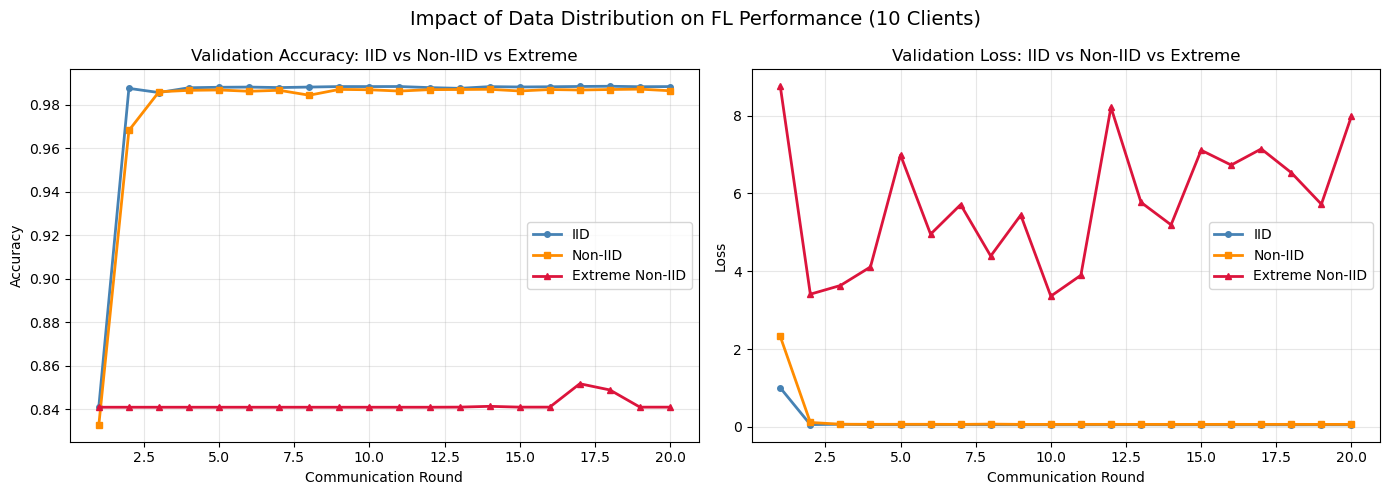

In [11]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(range(1, NUM_ROUNDS+1), iid_10c_acc,
         linewidth=2, marker='o', markersize=4, label='IID', color='steelblue')
ax1.plot(range(1, NUM_ROUNDS+1), noniid_10c_acc,
         linewidth=2, marker='s', markersize=4, label='Non-IID', color='darkorange')
ax1.plot(range(1, NUM_ROUNDS+1), extreme_acc,
         linewidth=2, marker='^', markersize=4, label='Extreme Non-IID', color='crimson')
ax1.set_title('Validation Accuracy: IID vs Non-IID vs Extreme')
ax1.set_xlabel('Communication Round')
ax1.set_ylabel('Accuracy')
ax1.legend()
ax1.grid(True, alpha=0.3)

ax2.plot(range(1, NUM_ROUNDS+1), iid_10c_loss,
         linewidth=2, marker='o', markersize=4, label='IID', color='steelblue')
ax2.plot(range(1, NUM_ROUNDS+1), noniid_10c_loss,
         linewidth=2, marker='s', markersize=4, label='Non-IID', color='darkorange')
ax2.plot(range(1, NUM_ROUNDS+1), extreme_loss,
         linewidth=2, marker='^', markersize=4, label='Extreme Non-IID', color='crimson')
ax2.set_title('Validation Loss: IID vs Non-IID vs Extreme')
ax2.set_xlabel('Communication Round')
ax2.set_ylabel('Loss')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.suptitle('Impact of Data Distribution on FL Performance (10 Clients)', fontsize=14)
plt.tight_layout()
plt.savefig(datapath + "fl_distribution_comparison.png", dpi=150)
plt.show()

---
## 11. Final Evaluation & Summary Table
**Requires:** All models loaded.

84993/84993 ━━━━━━━━━━━━━━━━━━━━ 186s 2ms/step

  IID (5c) - Test Metrics
  Accuracy : 0.9824
  Precision: 0.9838
  Recall   : 0.9824
  F1-Score : 0.9815

  Per-Class Report:
              precision    recall  f1-score   support

      Benign       0.99      1.00      1.00   2428646
         Bot       0.99      1.00      1.00     45983
 Brute Force       0.29      1.00      0.45     12012
        DDoS       1.00      1.00      1.00     91144
         DoS       1.00      0.76      0.86    124379
Infiltration       0.00      0.00      0.00     17453
  Web Attack       0.92      0.59      0.72       133

    accuracy                           0.98   2719750
   macro avg       0.74      0.76      0.72   2719750
weighted avg       0.98      0.98      0.98   2719750



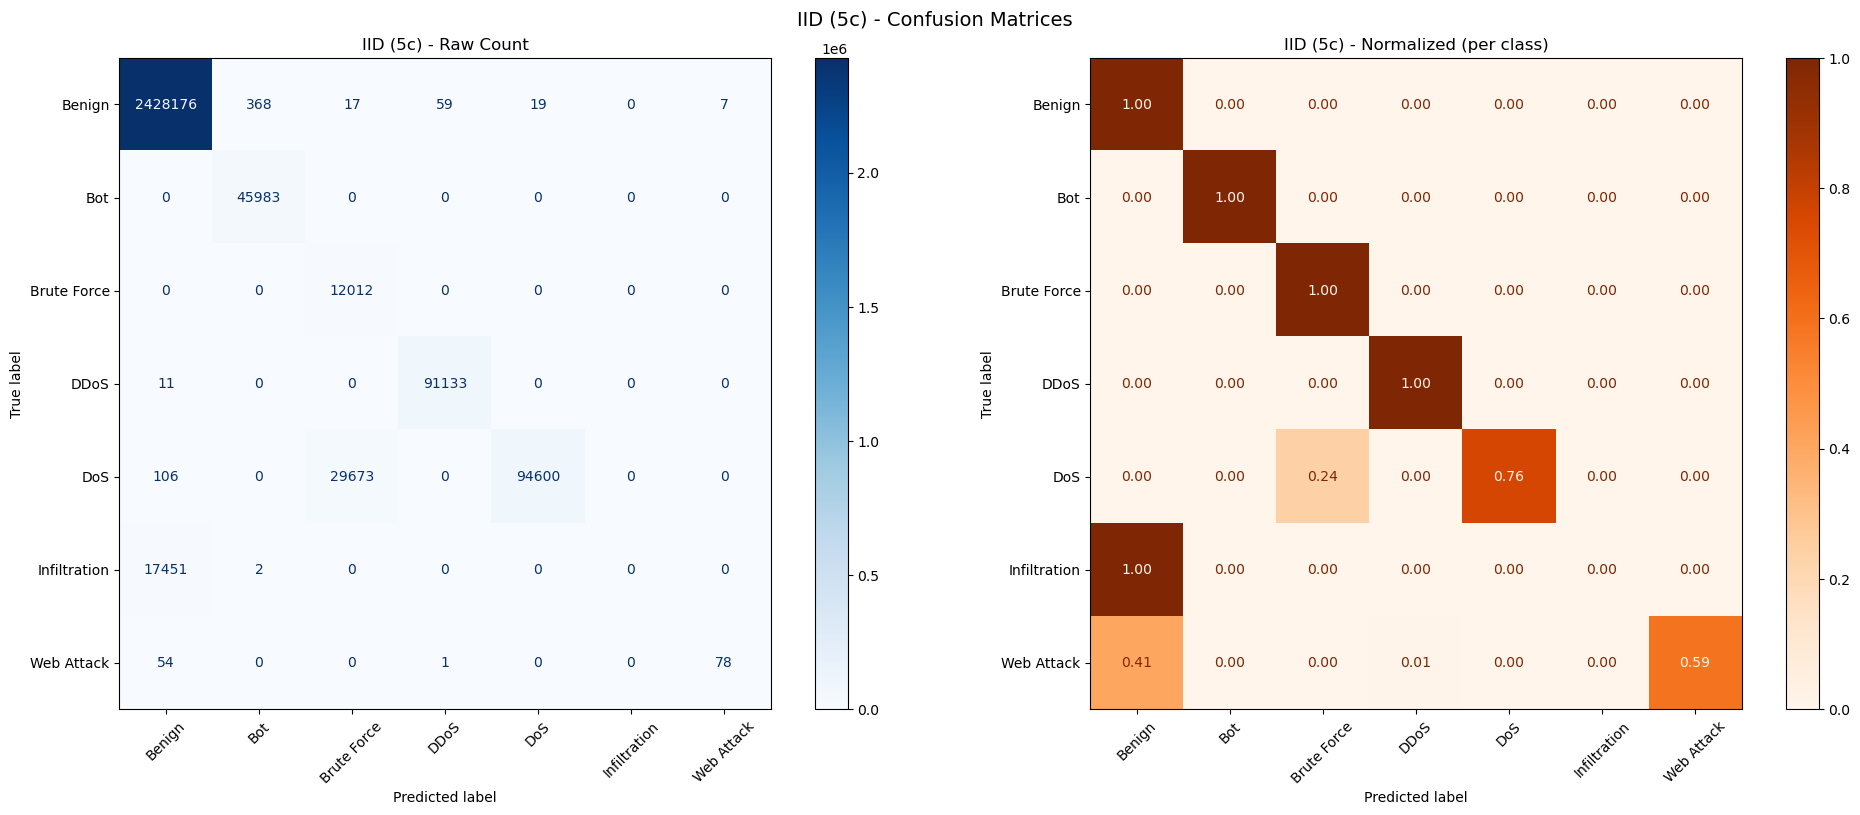

84993/84993 ━━━━━━━━━━━━━━━━━━━━ 218s 3ms/step

  IID (10c) - Test Metrics
  Accuracy : 0.9823
  Precision: 0.9837
  Recall   : 0.9823
  F1-Score : 0.9814

  Per-Class Report:
              precision    recall  f1-score   support

      Benign       0.99      1.00      1.00   2428646
         Bot       0.99      1.00      0.99     45983
 Brute Force       0.29      1.00      0.45     12012
        DDoS       1.00      1.00      1.00     91144
         DoS       1.00      0.76      0.86    124379
Infiltration       0.00      0.00      0.00     17453
  Web Attack       1.00      0.23      0.38       133

    accuracy                           0.98   2719750
   macro avg       0.75      0.71      0.67   2719750
weighted avg       0.98      0.98      0.98   2719750



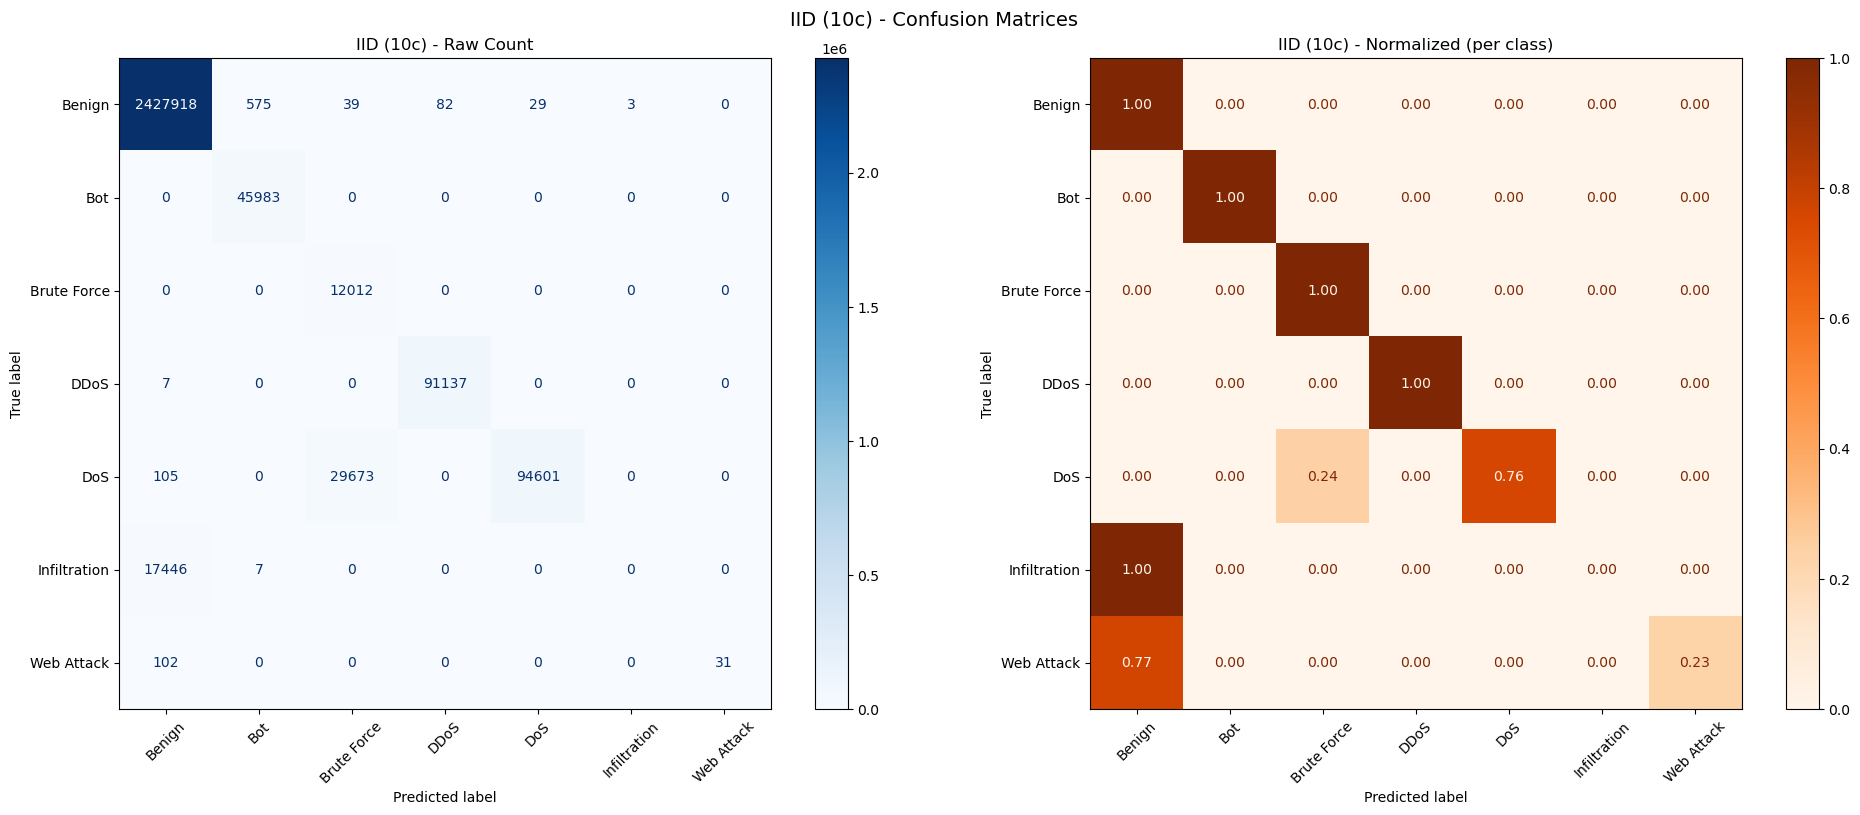

84993/84993 ━━━━━━━━━━━━━━━━━━━━ 228s 3ms/step

  IID (15c) - Test Metrics
  Accuracy : 0.9812
  Precision: 0.9842
  Recall   : 0.9812
  F1-Score : 0.9804

  Per-Class Report:
              precision    recall  f1-score   support

      Benign       0.99      1.00      1.00   2428646
         Bot       0.98      1.00      0.99     45983
 Brute Force       0.29      1.00      0.45     12012
        DDoS       0.97      1.00      0.99     91144
         DoS       1.00      0.76      0.86    124379
Infiltration       0.23      0.00      0.01     17453
  Web Attack       1.00      0.23      0.38       133

    accuracy                           0.98   2719750
   macro avg       0.78      0.71      0.67   2719750
weighted avg       0.98      0.98      0.98   2719750



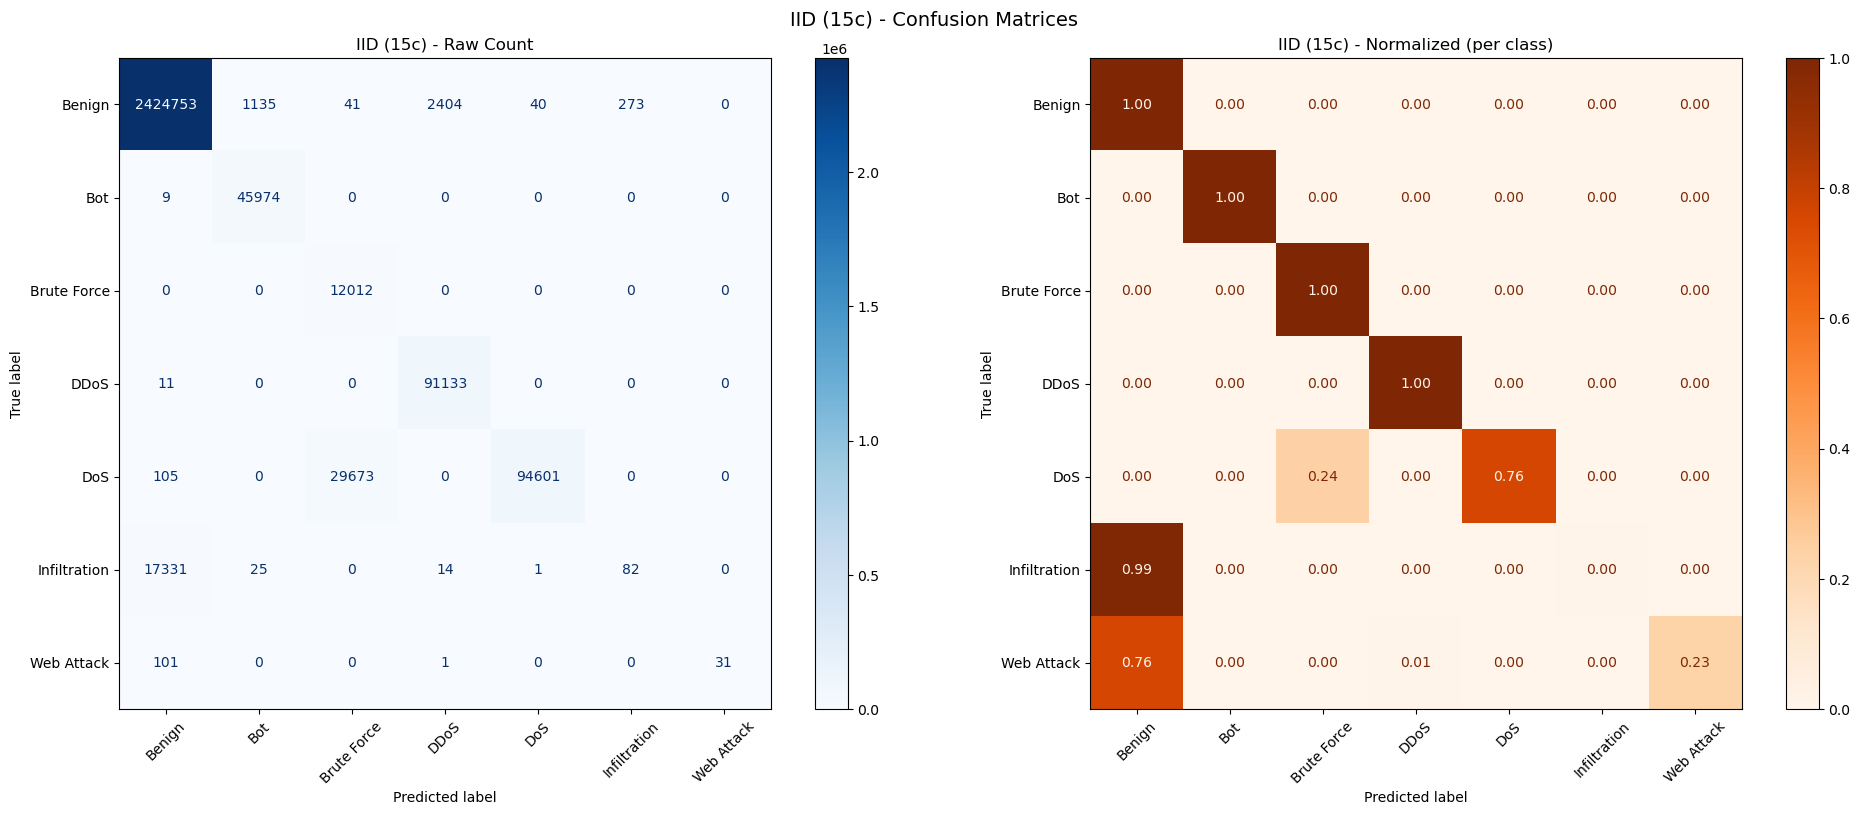

84993/84993 ━━━━━━━━━━━━━━━━━━━━ 226s 3ms/step

  Non-IID (5c) - Test Metrics
  Accuracy : 0.9822
  Precision: 0.9836
  Recall   : 0.9822
  F1-Score : 0.9813

  Per-Class Report:
              precision    recall  f1-score   support

      Benign       0.99      1.00      1.00   2428646
         Bot       0.99      1.00      1.00     45983
 Brute Force       0.29      1.00      0.45     12012
        DDoS       0.99      1.00      1.00     91144
         DoS       1.00      0.76      0.86    124379
Infiltration       0.00      0.00      0.00     17453
  Web Attack       1.00      0.23      0.37       133

    accuracy                           0.98   2719750
   macro avg       0.75      0.71      0.67   2719750
weighted avg       0.98      0.98      0.98   2719750



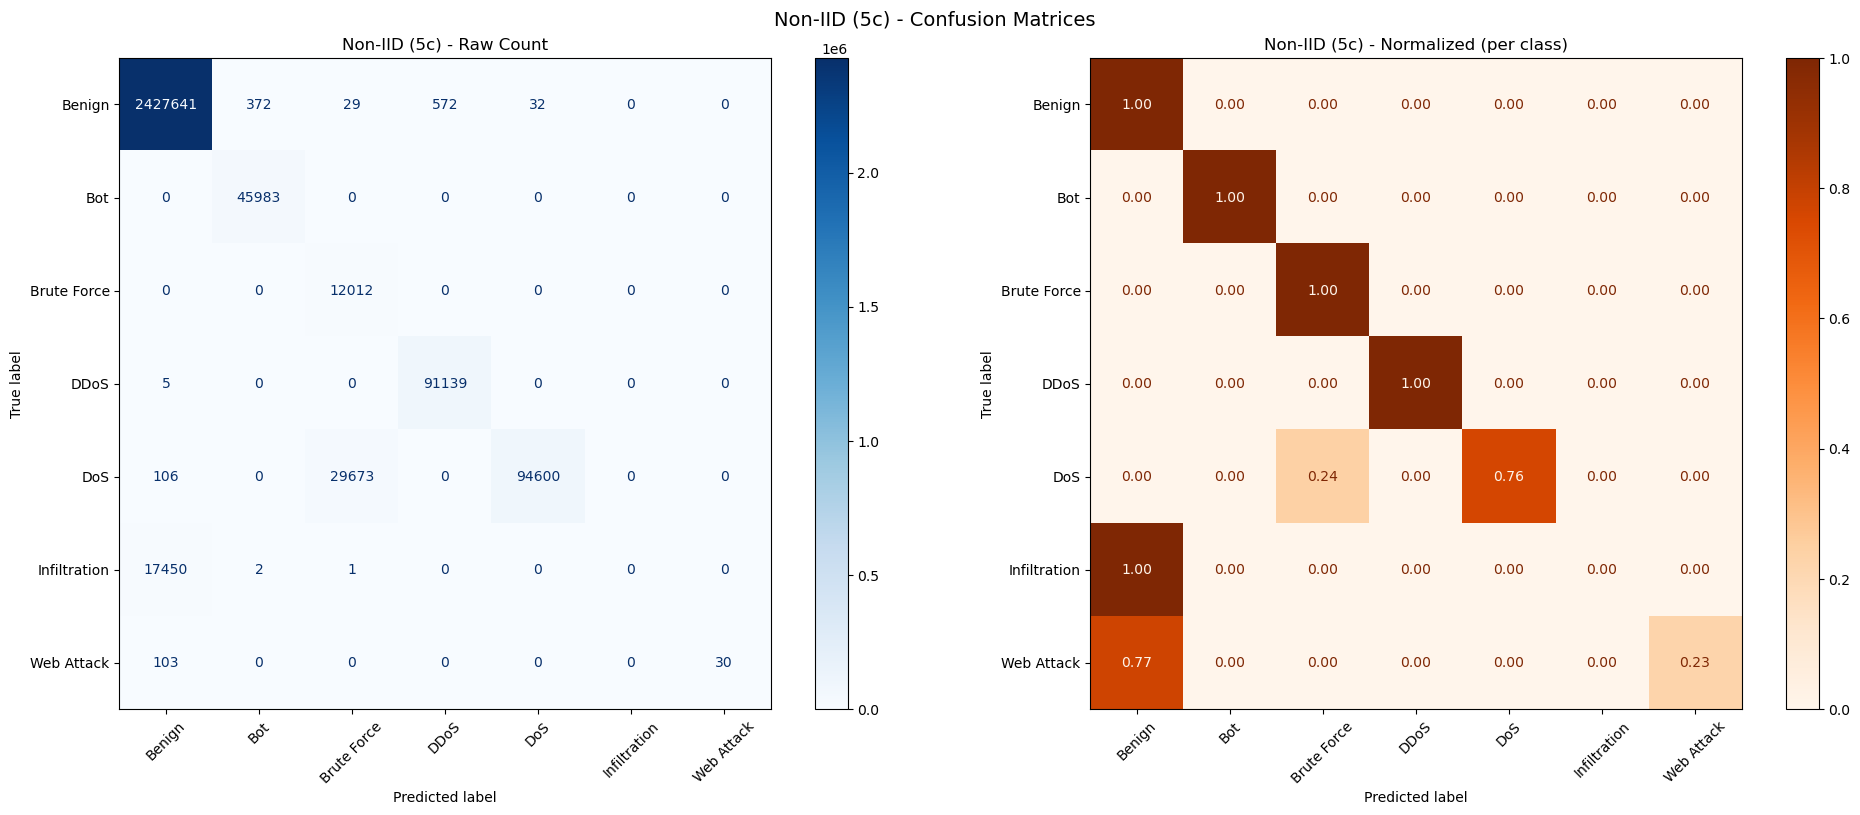

84993/84993 ━━━━━━━━━━━━━━━━━━━━ 225s 3ms/step

  Non-IID (10c) - Test Metrics
  Accuracy : 0.9802
  Precision: 0.9839
  Recall   : 0.9802
  F1-Score : 0.9803

  Per-Class Report:
              precision    recall  f1-score   support

      Benign       0.99      1.00      1.00   2428646
         Bot       0.99      0.96      0.98     45983
 Brute Force       0.29      1.00      0.45     12012
        DDoS       1.00      1.00      1.00     91144
         DoS       1.00      0.76      0.86    124379
Infiltration       0.12      0.03      0.05     17453
  Web Attack       0.00      0.00      0.00       133

    accuracy                           0.98   2719750
   macro avg       0.63      0.68      0.62   2719750
weighted avg       0.98      0.98      0.98   2719750



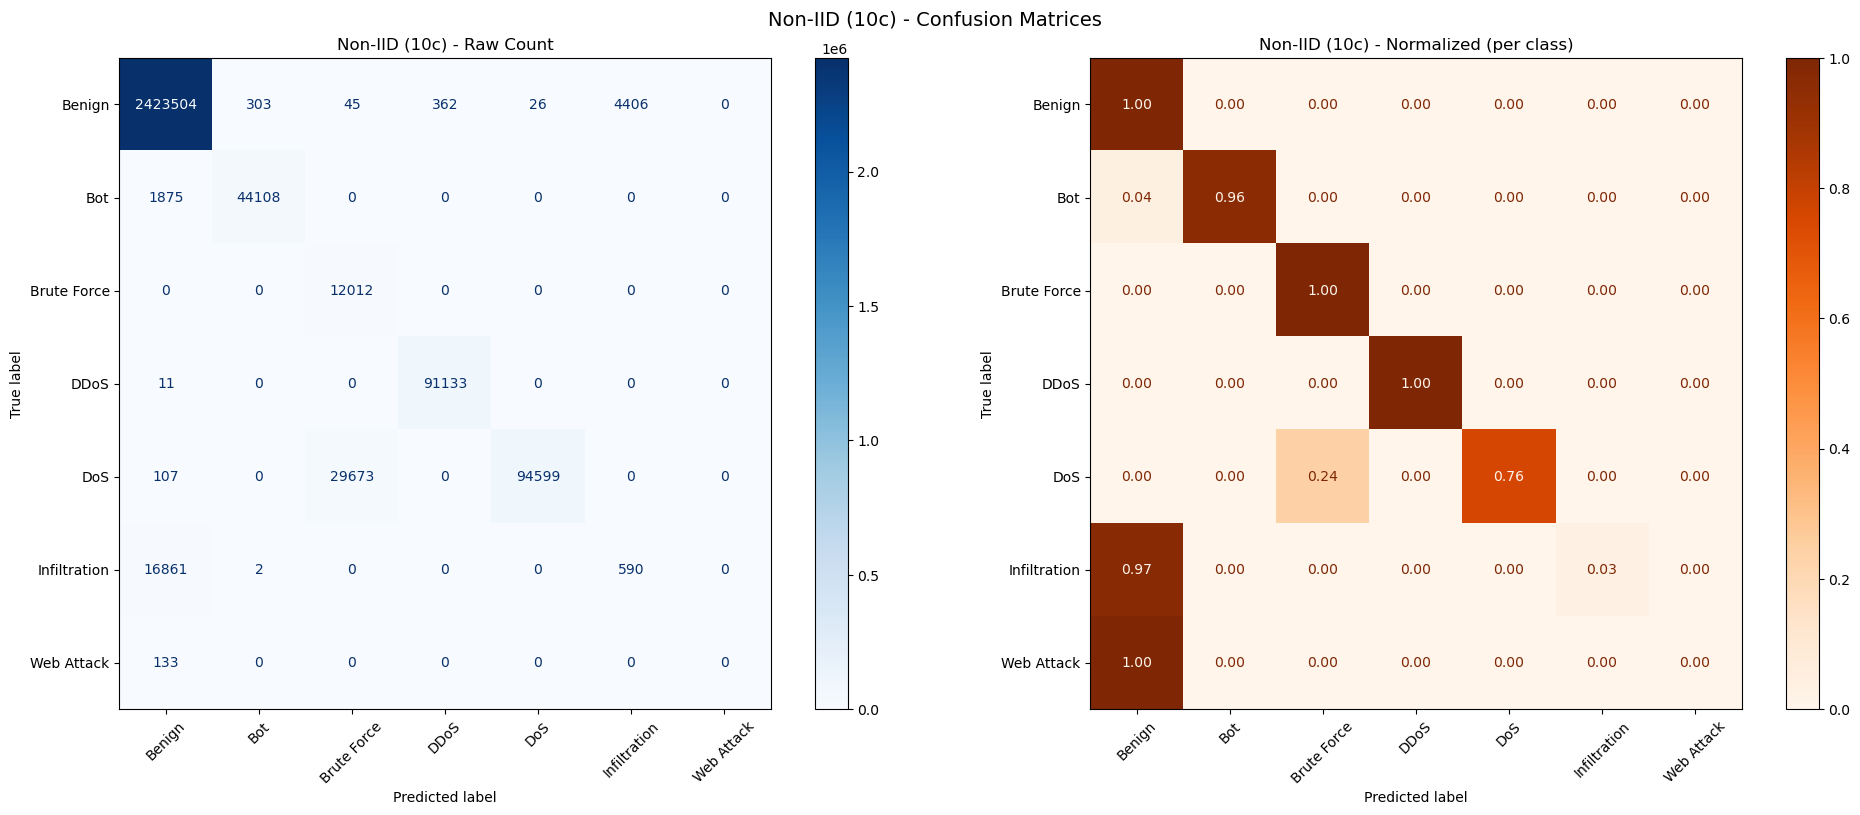

84993/84993 ━━━━━━━━━━━━━━━━━━━━ 241s 3ms/step

  Non-IID (15c) - Test Metrics
  Accuracy : 0.9818
  Precision: 0.9832
  Recall   : 0.9818
  F1-Score : 0.9808

  Per-Class Report:
              precision    recall  f1-score   support

      Benign       0.99      1.00      1.00   2428646
         Bot       1.00      0.96      0.98     45983
 Brute Force       0.29      1.00      0.45     12012
        DDoS       1.00      1.00      1.00     91144
         DoS       1.00      0.76      0.86    124379
Infiltration       0.00      0.00      0.00     17453
  Web Attack       0.00      0.00      0.00       133

    accuracy                           0.98   2719750
   macro avg       0.61      0.67      0.61   2719750
weighted avg       0.98      0.98      0.98   2719750



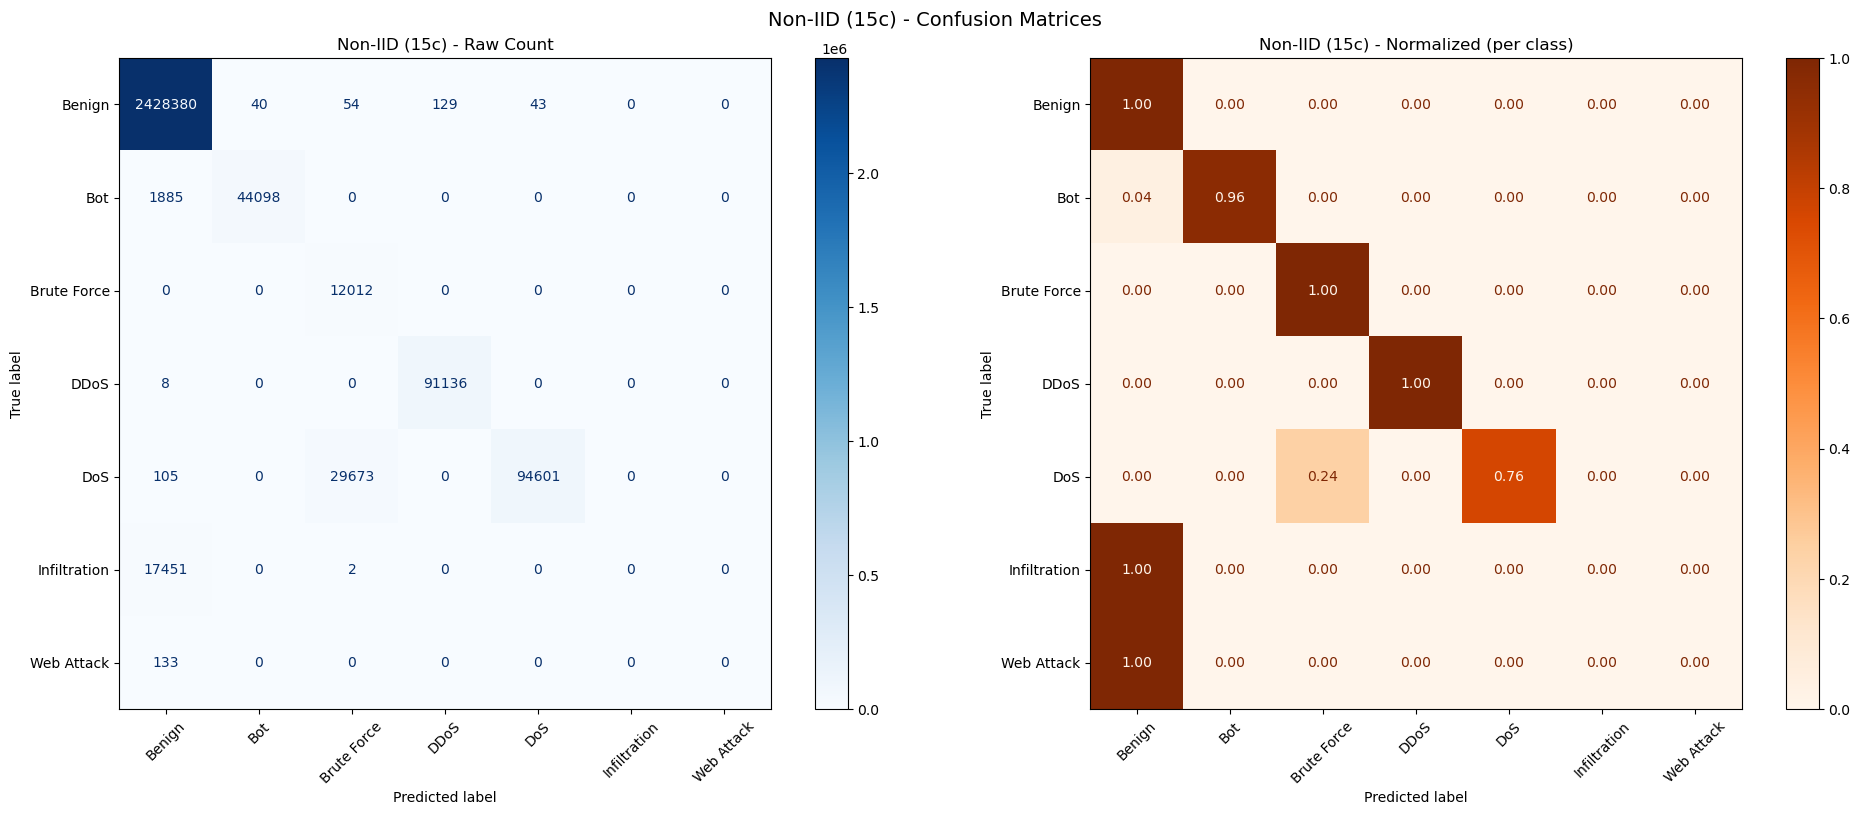

84993/84993 ━━━━━━━━━━━━━━━━━━━━ 225s 3ms/step

  Extreme Non-IID (10c) - Test Metrics
  Accuracy : 0.8936
  Precision: 0.8314
  Recall   : 0.8936
  F1-Score : 0.8440

  Per-Class Report:
              precision    recall  f1-score   support

      Benign       0.89      1.00      0.94   2428646
         Bot       0.00      0.00      0.00     45983
 Brute Force       0.00      0.00      0.00     12012
        DDoS       1.00      0.02      0.04     91144
         DoS       0.00      0.00      0.00    124379
Infiltration       0.00      0.00      0.00     17453
  Web Attack       0.00      0.00      0.00       133

    accuracy                           0.89   2719750
   macro avg       0.27      0.15      0.14   2719750
weighted avg       0.83      0.89      0.84   2719750



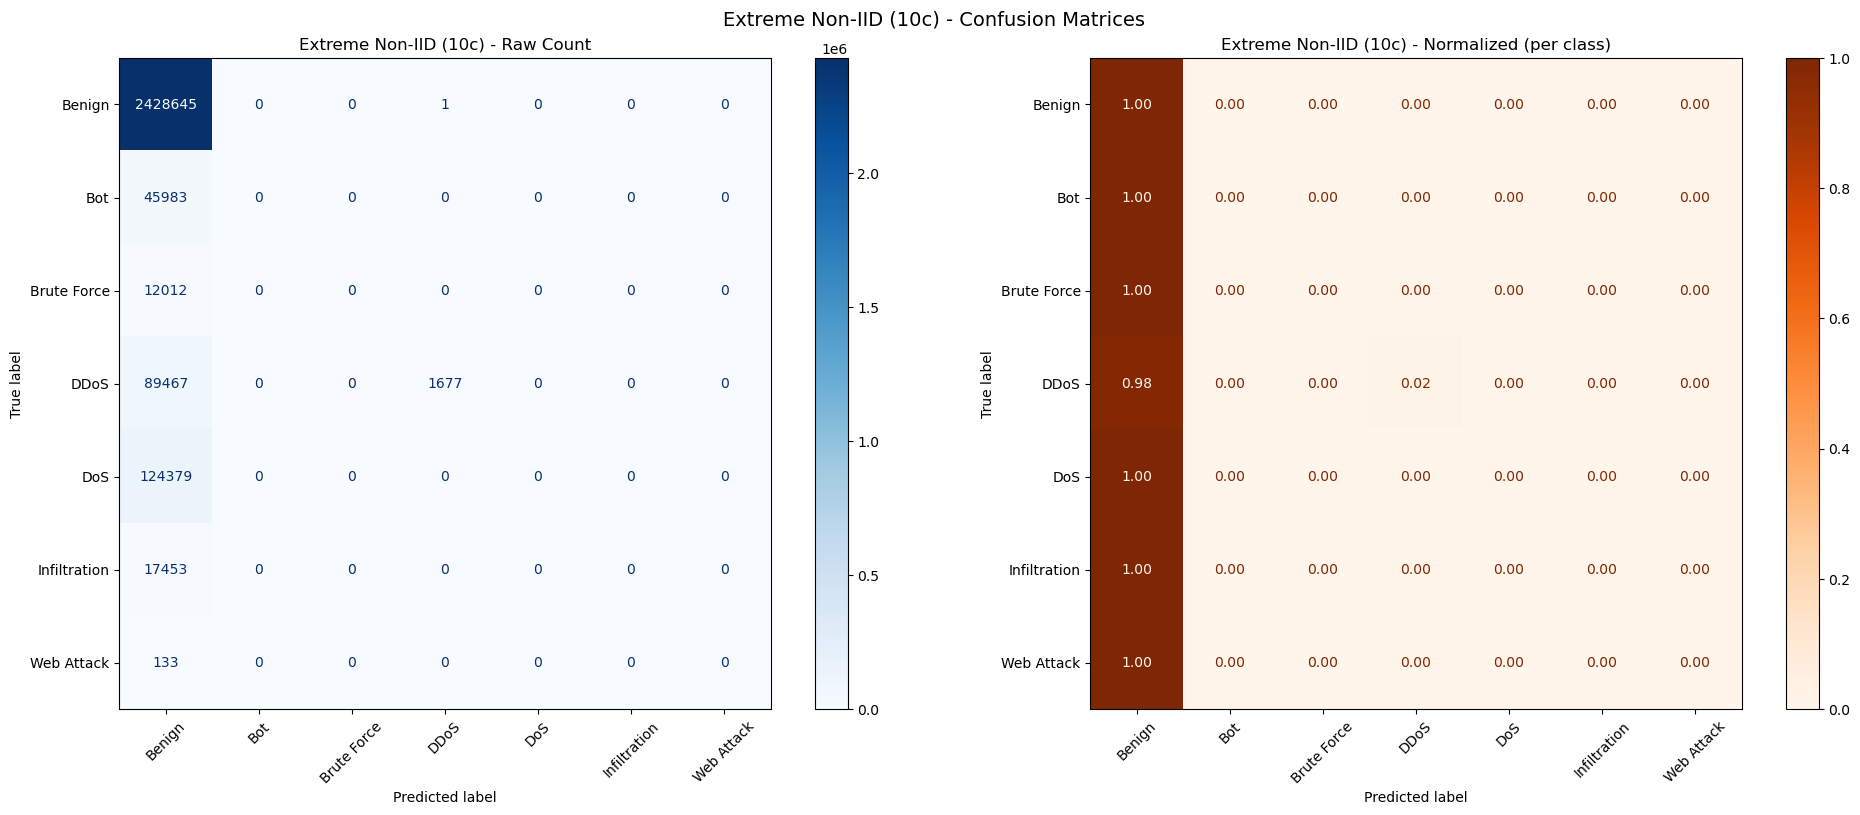


  FINAL SUMMARY: All Experiments


,Experiment,Best Val Acc,Test Accuracy,Test Precision,Test Recall,Test F1
0,IID (5c),0.9886,0.9824,0.9838,0.9824,0.9815
1,IID (10c),0.9886,0.9823,0.9837,0.9823,0.9814
2,IID (15c),0.9882,0.9812,0.9842,0.9812,0.9804
3,Non-IID (5c),0.9885,0.9822,0.9836,0.9822,0.9813
4,Non-IID (10c),0.9872,0.9802,0.9839,0.9802,0.9803
5,Non-IID (15c),0.9873,0.9818,0.9832,0.9818,0.9808
6,Extreme Non-IID (10c),0.8517,0.8936,0.8314,0.8936,0.8440


Summary saved to fl_summary_table.csv


In [12]:
summary_rows = []

experiments = [
    ("IID (5c)",  iid_5c_model,  iid_5c_acc),
    ("IID (10c)", iid_10c_model, iid_10c_acc),
    ("IID (15c)", iid_15c_model, iid_15c_acc),
    ("Non-IID (5c)",  noniid_5c_model,  noniid_5c_acc),
    ("Non-IID (10c)", noniid_10c_model, noniid_10c_acc),
    ("Non-IID (15c)", noniid_15c_model, noniid_15c_acc),
    ("Extreme Non-IID (10c)", extreme_model, extreme_acc),
]

for name, model, val_acc in experiments:
    metrics = evaluate_model(model, X_test_cnn, y_test, label=name)
    metrics['Experiment'] = name
    metrics['Best Val Acc'] = max(val_acc)
    summary_rows.append(metrics)

df_summary = pd.DataFrame(summary_rows)
df_summary = df_summary[['Experiment','Best Val Acc','accuracy','precision','recall','f1']]
df_summary.columns = ['Experiment','Best Val Acc','Test Accuracy','Test Precision','Test Recall','Test F1']
df_summary = df_summary.round(4)

print("\n" + "="*80)
print("  FINAL SUMMARY: All Experiments")
print("="*80)
display(df_summary)

df_summary.to_csv(datapath + "fl_summary_table.csv", index=False)
print("Summary saved to fl_summary_table.csv")

84993/84993 ━━━━━━━━━━━━━━━━━━━━ 215s 3ms/step


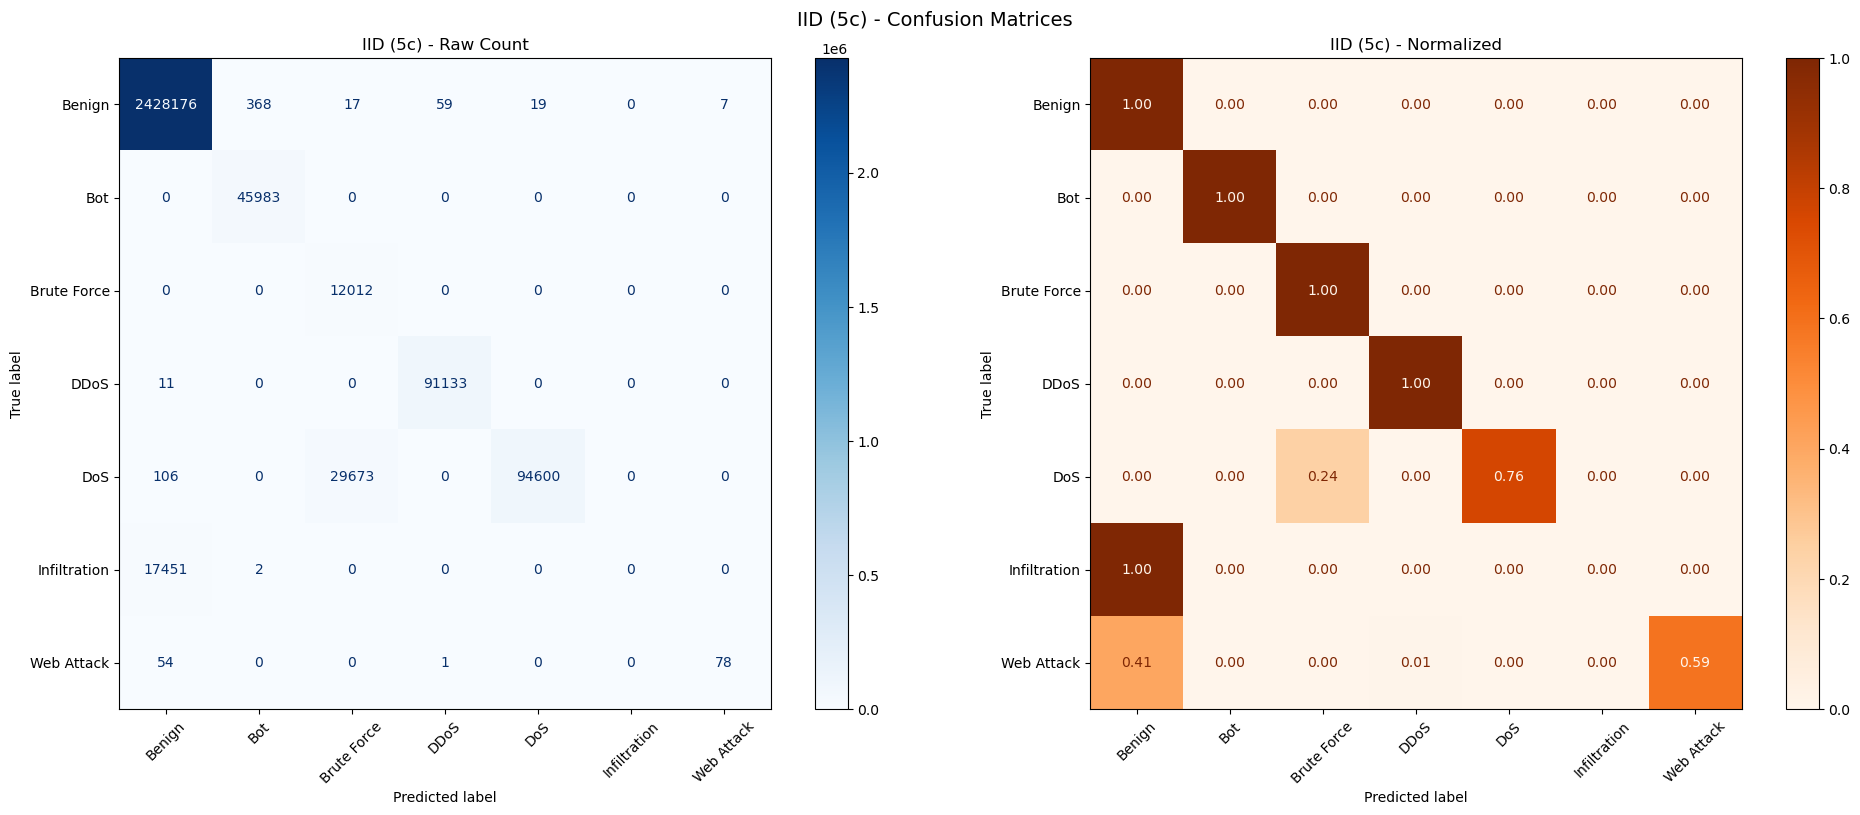

Saved: cm_IID_5c.png
84993/84993 ━━━━━━━━━━━━━━━━━━━━ 224s 3ms/step


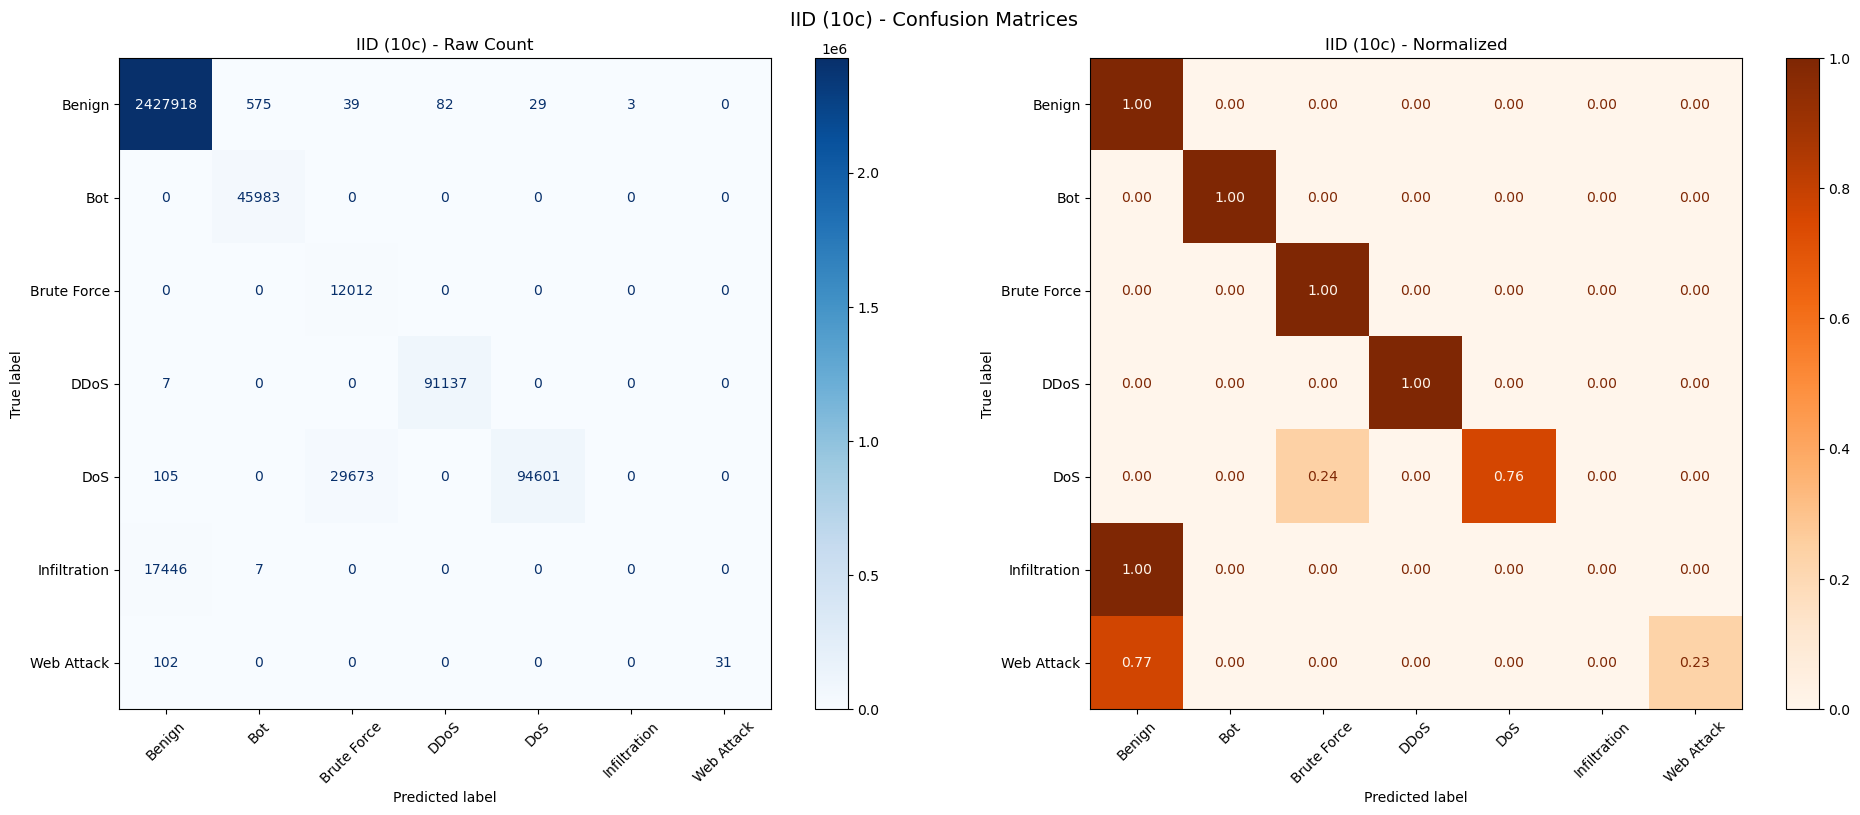

Saved: cm_IID_10c.png
84993/84993 ━━━━━━━━━━━━━━━━━━━━ 219s 3ms/step


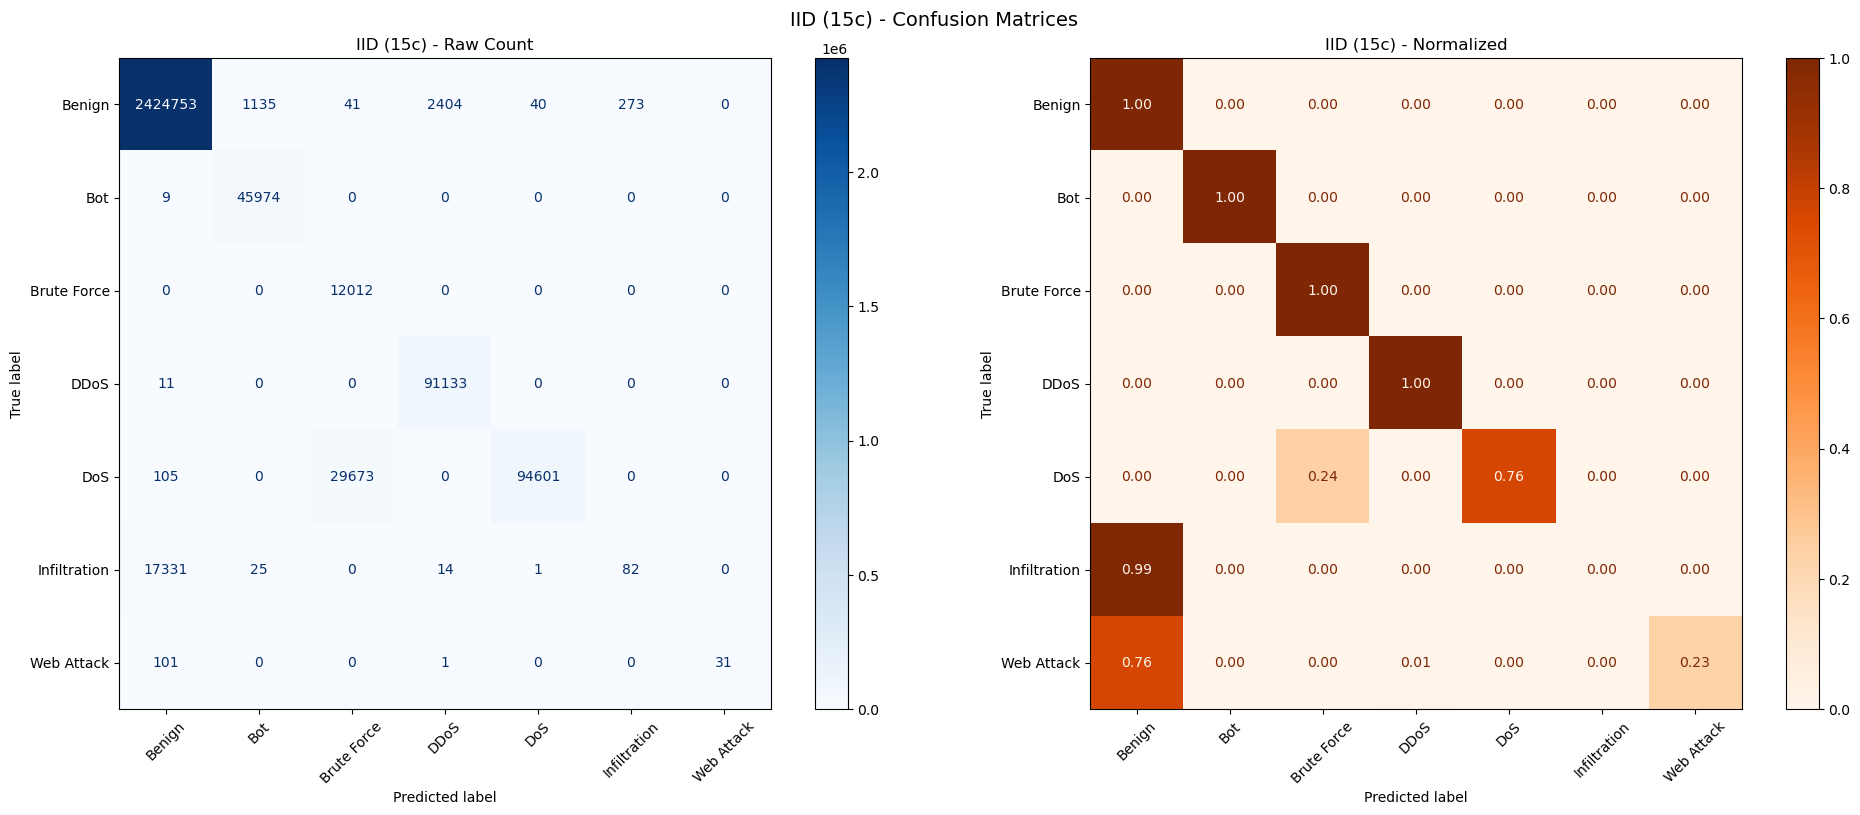

Saved: cm_IID_15c.png
84993/84993 ━━━━━━━━━━━━━━━━━━━━ 216s 3ms/step


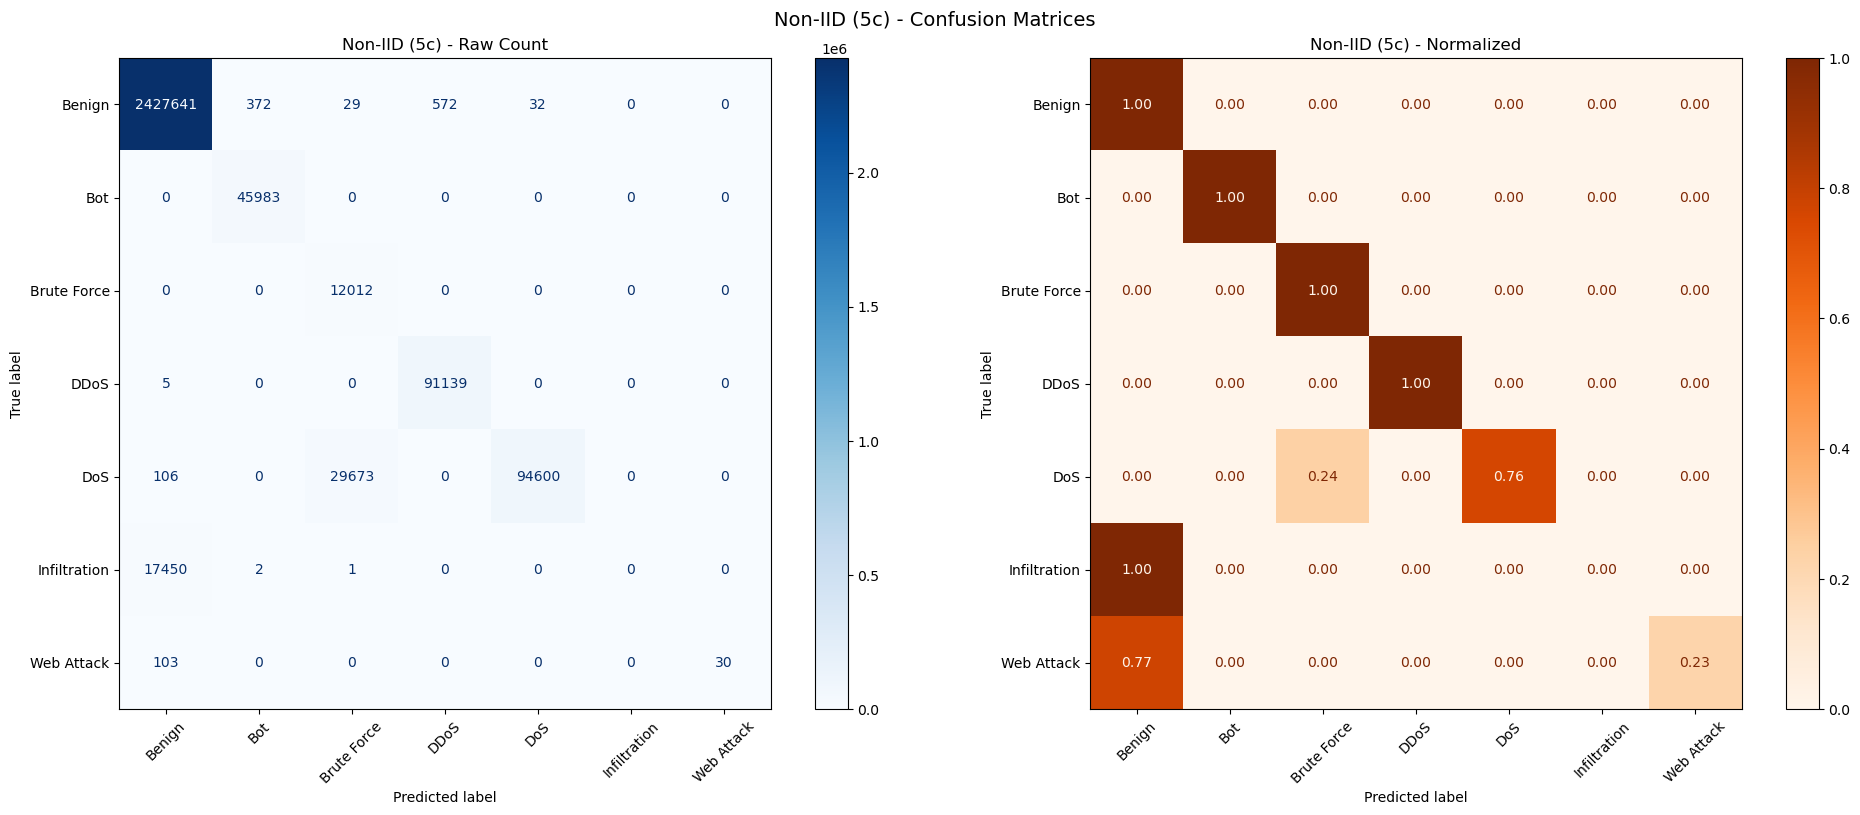

Saved: cm_Non-IID_5c.png
84993/84993 ━━━━━━━━━━━━━━━━━━━━ 222s 3ms/step


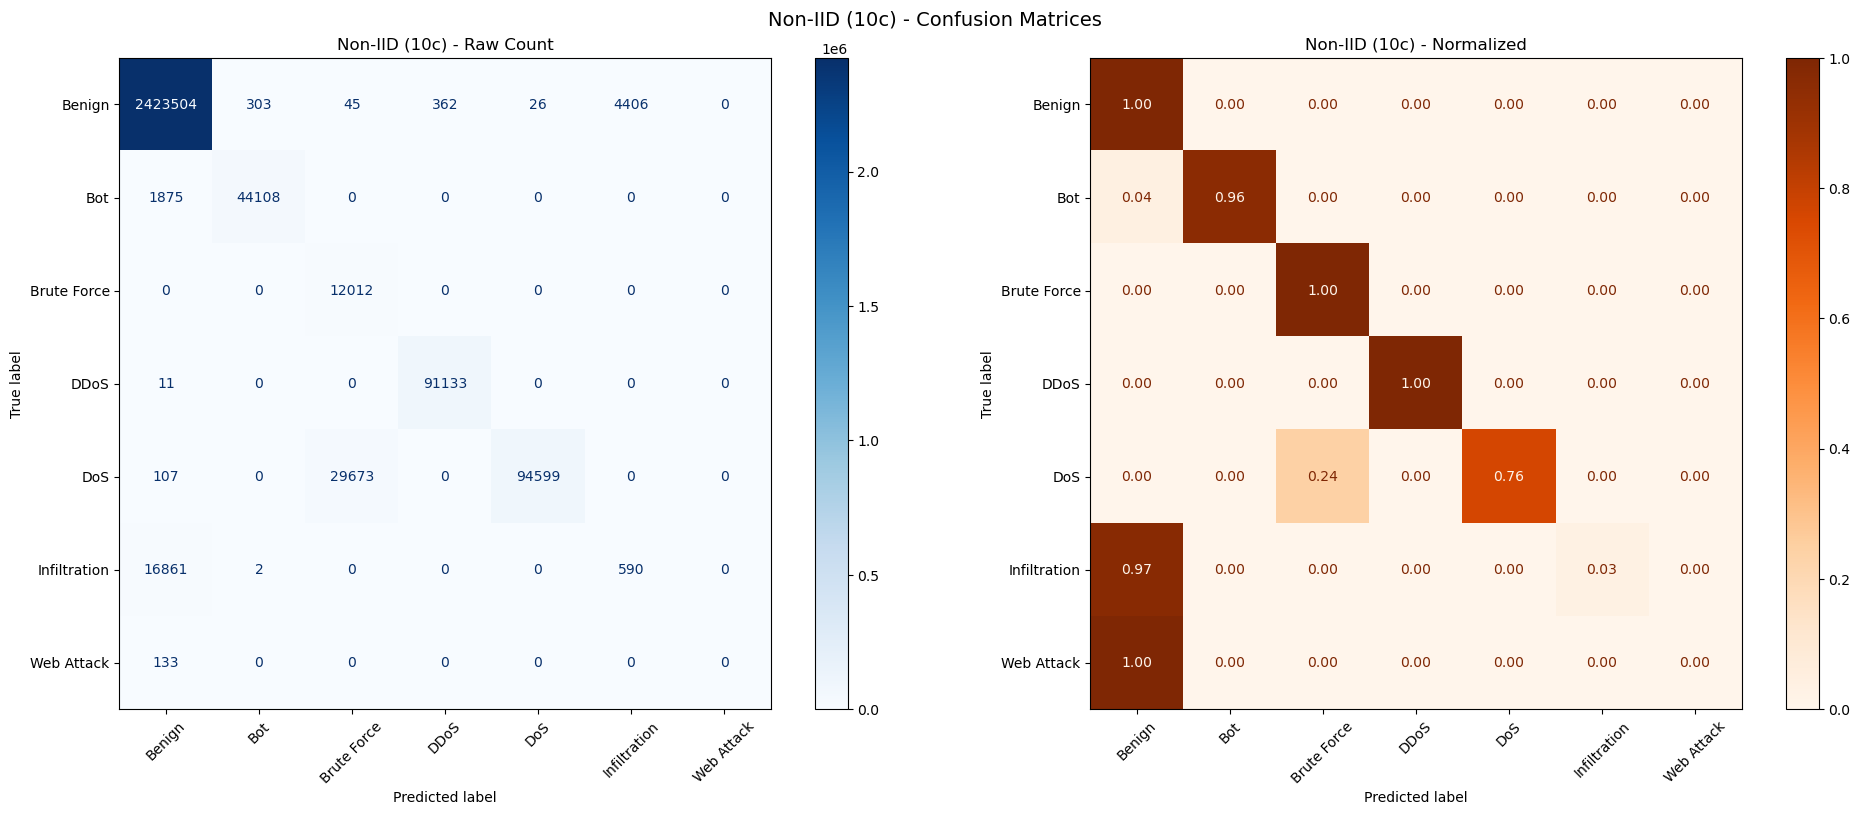

Saved: cm_Non-IID_10c.png
84993/84993 ━━━━━━━━━━━━━━━━━━━━ 225s 3ms/step


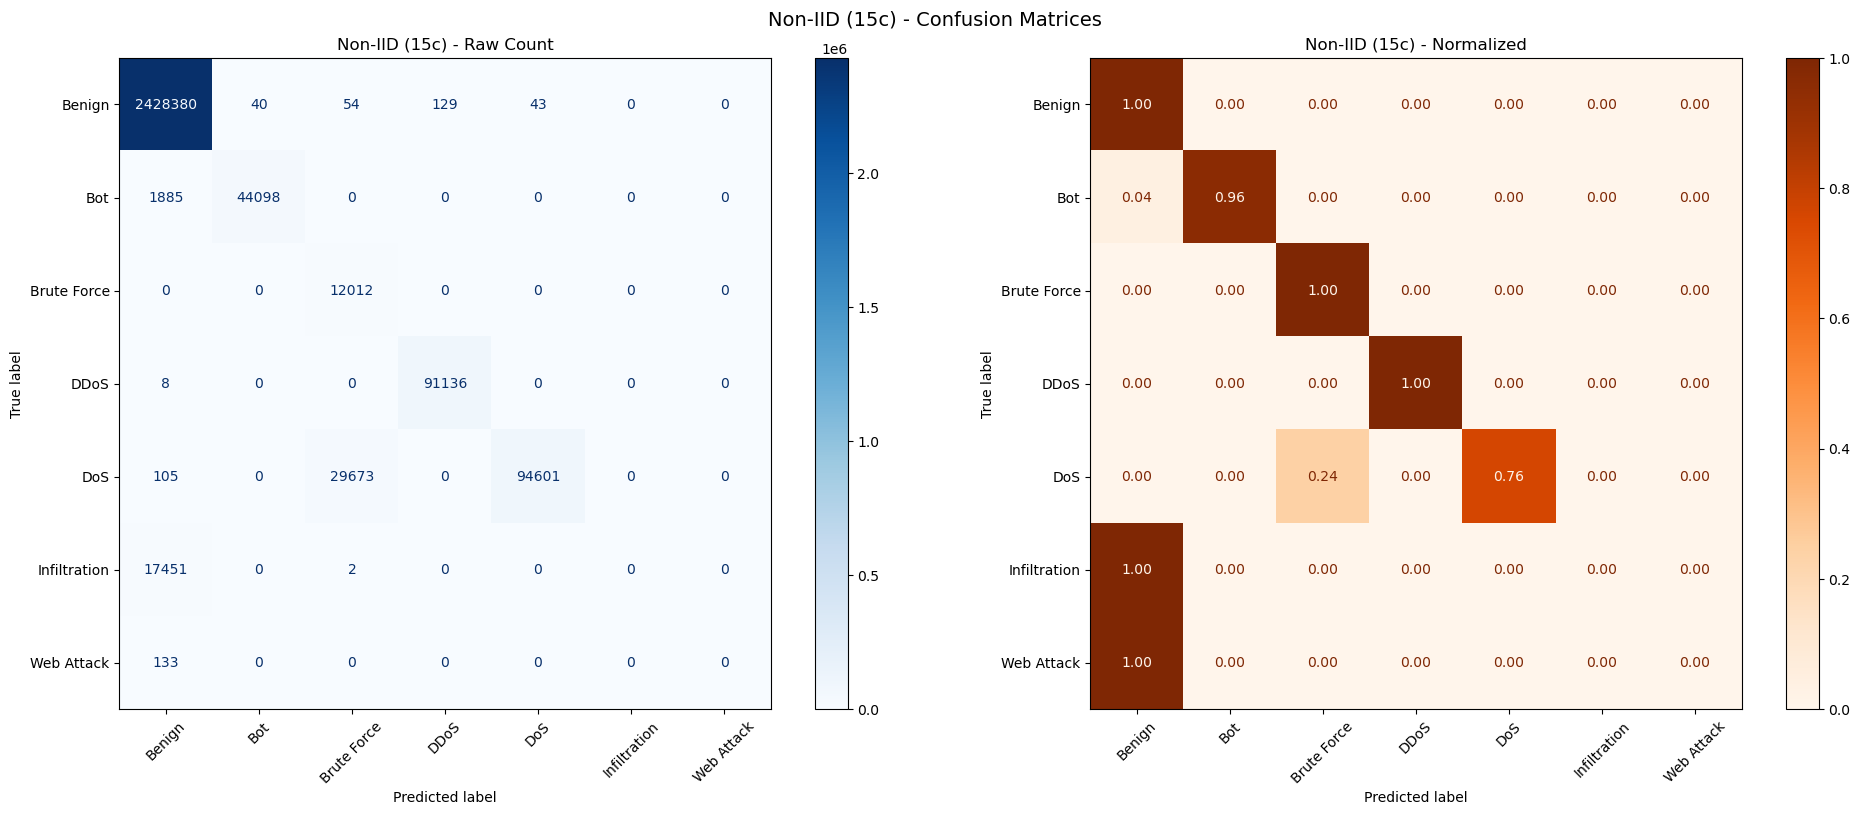

Saved: cm_Non-IID_15c.png
84993/84993 ━━━━━━━━━━━━━━━━━━━━ 228s 3ms/step


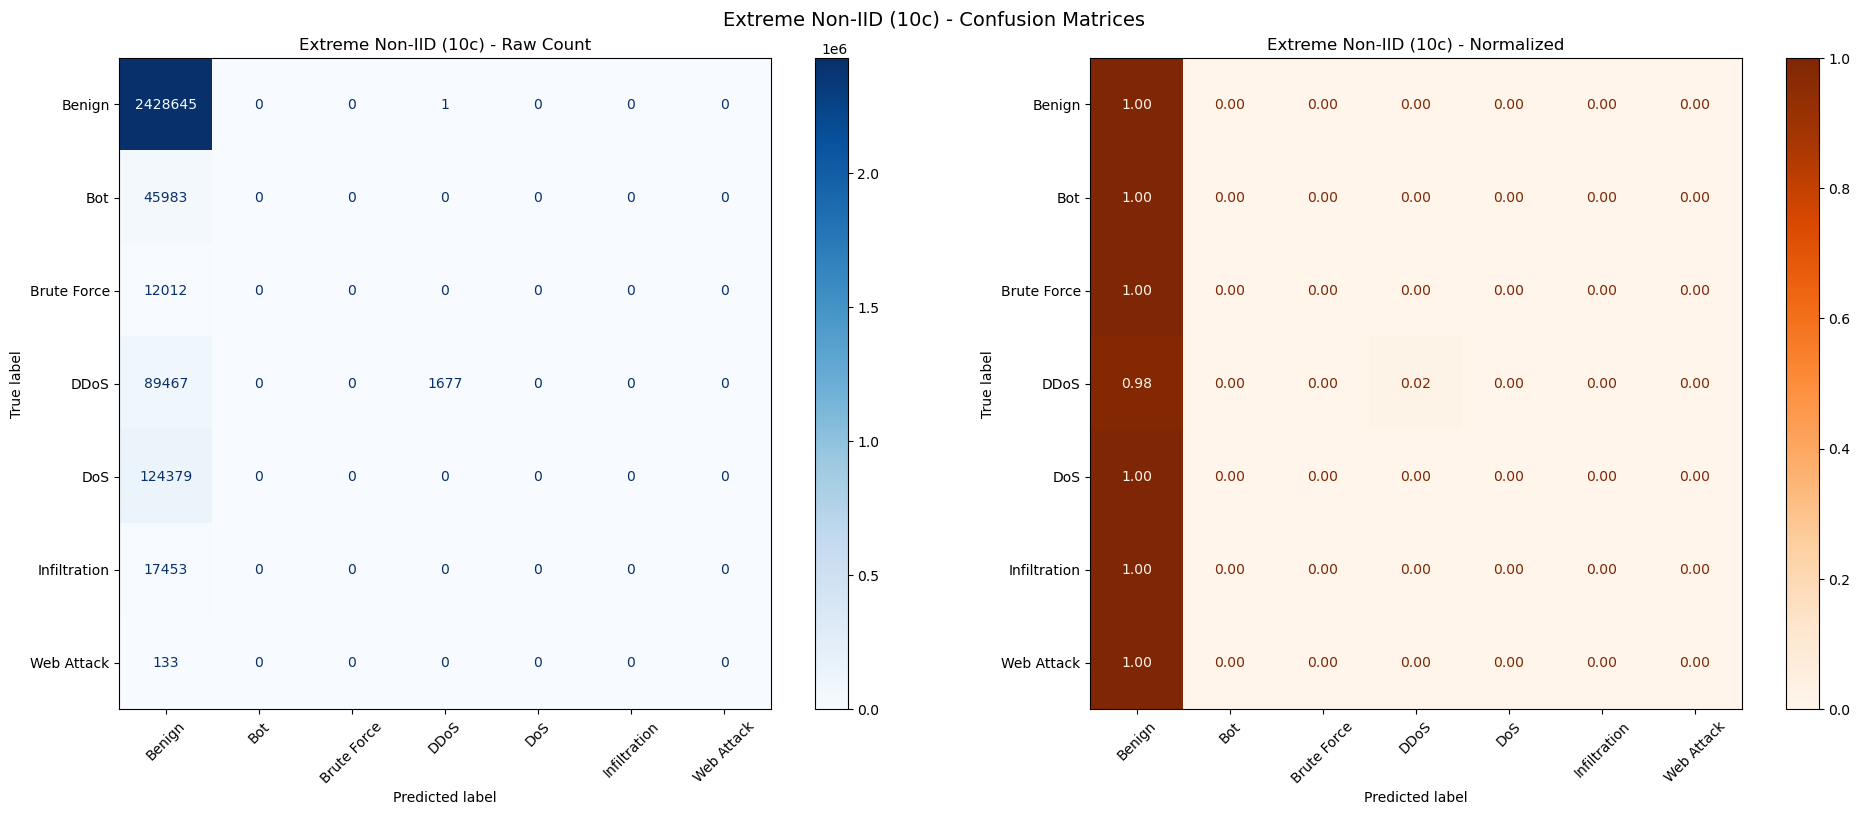

Saved: cm_Extreme_Non-IID_10c.png


In [13]:
for name, model, val_acc in experiments:
    y_pred_prob = model.predict(X_test_cnn)
    y_pred = np.argmax(y_pred_prob, axis=1)
    
    unique_labels = sorted(list(set(y_test) | set(y_pred)))
    attack_type_names = [ATTACK_NAMES[l] for l in unique_labels]
    cm = confusion_matrix(y_test, y_pred, labels=unique_labels)
    cm_norm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
    cm_norm = np.nan_to_num(cm_norm)
    
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 8))
    ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=attack_type_names).plot(cmap="Blues", values_format="d", xticks_rotation=45, ax=ax1)
    ax1.set_title(f"{name} - Raw Count")
    ConfusionMatrixDisplay(confusion_matrix=cm_norm, display_labels=attack_type_names).plot(cmap="Oranges", values_format=".2f", xticks_rotation=45, ax=ax2)
    ax2.set_title(f"{name} - Normalized")
    plt.suptitle(f"{name} - Confusion Matrices", fontsize=14)
    plt.tight_layout()
    
    safe_name = name.replace(" ", "_").replace("(", "").replace(")", "")
    plt.savefig(datapath + f"cm_{safe_name}.png", dpi=150)
    plt.show()
    print(f"Saved: cm_{safe_name}.png")